In [1]:
# Optional setup cell.
# Keep commented for final delivery and reproducibility via requirements files.
# %pip install -U pip

In [2]:
# Optional setup cell.
# Uncomment only if your environment is missing these dependencies.
# %pip install kagglehub pandas matplotlib geopandas scikit-learn umap-learn

In [3]:

import pandas as pd
import numpy as np
import datetime
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import geopandas as gpd
import seaborn as sns
from scipy.stats import entropy
from sklearn.preprocessing import OneHotEncoder
import os


Import persnal libs

In [4]:
from statlib.dissimilarity import parallel_dissimilarity_matrix

"""
'NO' : Nominal
'NU' : Numerical
'SB' : Symmetric Binary (EG male/female)
'AB' : Asymmetric Binary
'TX' : Text/String using TF-IDF (single-word bag of words) + cosine dissimilarity
"""

dict_types = {
    "YEAR": "NU",                    # Numerical - int64
    "MONTH": "NU",                   # Numerical - int64
    "DAY": "NU",                     # Numerical - int64
    "DAY_OF_WEEK": "NU",             # Numerical - int64
    "AIRLINE": "NO",                 # Nominal   - str
    "FLIGHT_NUMBER": "NU",           # Numerical - int64
    "TAIL_NUMBER": "NO",             # Nominal   - str
    "ORIGIN_AIRPORT": "NO",          # Nominal   - object
    "DESTINATION_AIRPORT": "NO",     # Nominal   - object
    "SCHEDULED_DEPARTURE": "NU",     # Numerical - int64
    "DEPARTURE_TIME": "NU",          # Numerical - float64
    "DEPARTURE_DELAY": "NU",         # Numerical - float64
    "TAXI_OUT": "NU",                # Numerical - float64
    "WHEELS_OFF": "NU",              # Numerical - float64
    "SCHEDULED_TIME": "NU",          # Numerical - float64
    "ELAPSED_TIME": "NU",            # Numerical - float64
    "AIR_TIME": "NU",                # Numerical - float64
    "DISTANCE": "NU",                # Numerical - int64
    "WHEELS_ON": "NU",               # Numerical - float64
    "TAXI_IN": "NU",                 # Numerical - float64
    "SCHEDULED_ARRIVAL": "NU",       # Numerical - int64
}

# do we need this metric?

## For a fast implementation we must split the dataset 

The best result when wh try to split a dataset is when the distribution between initial and 
partitioned dataset are most similar, the we can try to misure dissimilarity using dinstance

We will do this only for big table

# Distribution comparison metrics and tests


## **TESTS:**

* Two-sample t-test
* Mann-Whitney U-test
* Pearson $\chi^2$ test

---

**Formula (Two-sample t-test):**
$$
t=\frac{\bar{x}_1-\bar{x}_2}
{\sqrt{
\frac{s_1^2}{n_1}+\frac{s_2^2}{n_2}
}}
$$

Interpretation:

* Tests whether two population means are significantly different.
* Assumes approximately normal distributions.

Example:

* Compare average delays between two airlines.

Python:

```python
from scipy.stats import ttest_ind

ttest_ind(x1, x2)
```

---

**Formula (Mann-Whitney U-test):**
$$
U=n_1n_2+\frac{n_1(n_1+1)}{2}-R_1
$$

where:

* $R_1$ is the rank sum of sample 1.

Interpretation:

* Non-parametric alternative to the t-test.
* Compares rank distributions instead of means.

Example:

* Compare delays between airlines without assuming Gaussian distributions.

Python:

```python
from scipy.stats import mannwhitneyu

mannwhitneyu(x1, x2)
```

---

**Formula (Pearson $\chi^2$ test):**
$$
\chi^2=\sum_i\frac{(O_i-E_i)^2}{E_i}
$$

where:

* $O_i$ = observed frequencies
* $E_i$ = expected frequencies

Interpretation:

* Tests independence between categorical variables.
* Measures discrepancy between observed and expected counts.

Example:

* Test whether cancellation reason depends on airline.

Python:

```python
from scipy.stats import chi2_contingency

chi2_contingency(table)
```

---

# Visual distribution comparison

## **VISUAL METHODS:**

* QQ-plot
* Overlapped histograms

---

**Formula (QQ-plot quantile mapping):**
$$
Q_X(p);\text{vs};Q_Y(p)
$$

Interpretation:

* Compares quantiles of two distributions.
* Detects shifts, scaling differences, skewness, and tail differences.

Example:

* If points follow the diagonal, distributions are similar.

---

**Formula (Histogram approximation):**
$$
\hat{p}(x)=\frac{\text{count in bin}}{n\cdot \text{bin width}}
$$

Interpretation:

* Visual approximation of empirical density.
* Useful for fast qualitative comparison.

Example:

* Overlapping histograms reveal shape differences, skewness, and multimodality.

---

In [ ]:
# load from kaggle and split into sample and original
from statlib.domain_tools import load_datasets


ds_name_list = ["airlines.csv","airports.csv","flights.csv"]
df_full = load_datasets(ds_name_list, omogenize=True)


/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading airlines.csv...
Loading airports.csv...
Loading flights.csv...


/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/kagglehub/pandas_datasets.py:92: DtypeWarning: Columns (0: ORIGIN_AIRPORT, 1: DESTINATION_AIRPORT) have mixed types. Specify dtype option on import or set low_memory=False.
  result = read_function(


## **METRICS:**

- KL-divergence
- Jensen-Shannon divergence
- Wasserstein distance


### Kullback-Leibler  divergence

![image](img/Kullback-Leibler.png)


The KL divergence of from $q$, measures the information loss when is used to approximate $p$. 

$$
D_{KL}(P\parallel Q)=\sum_i P(i)\log\frac{P(i)}{Q(i)}
$$


$$
D_{KL}(P||Q)=\int P(x)\log\frac{P(x)}{Q(x)}dx
$$

Properties:
- is not symmetric;
- it does not satisfy triangular inequality $D_{KL}(P||Q) \neq D_{KL}(Q||P)$.
- is non-negative $0$ iif $P=Q$; 
- divergent $\infty$

Example:
- Large KL-divergence means the approximation distribution misses important probability mass regions.
- Small KL-divergence means distributions are similar.

Python:
```python
from scipy.special import rel_entr
P = np.array([0.21, 0.21, 0.32, 0.26])
Q = np.array([0.00, 0.42, 0.32, 0.26])
kl = np.sum(rel_entr(P, Q))
```



### Jensen-Shannon divergence

![image](img/Jensen-Shannon.png)

Symmetric and smoothed version of KL-divergence. Measures distribution similarity more robustly than KL.



JS-divergence:
$$
JS(P,Q)=\frac{1}{2}D_{KL}(P||M)+\frac{1}{2}D_{KL}(Q||M)
$$

Properties:

* Symmetric: $JS(P,Q)=JS(Q,P)$ 
* Always finite.
* Bounded: $0\le JS\le\log(2)$

Example:

* Two nearly identical distributions give JS-distance close to 0.
* Completely different distributions give larger values.

Python:

```python
from scipy.spatial.distance import jensenshannon
# normalized vector
P = np.array([0.21, 0.21, 0.32, 0.26])
Q = np.array([0.00, 0.42, 0.32, 0.26])
js = jensenshannon(P, Q)
```

Return: $\sqrt{JS(P,Q)}$

---

### Wasserstein/Kantorovich distance (Earth Mover Distance)


![image](img/Wasserstein-Kantorovich.png)

Measures the minimum transport cost needed to slide one distribution into another. Interpreted as moving probability "mass".


$$
W(P,Q)=\inf_{\gamma\in\Gamma(P,Q)}
\int |x-y|, d\gamma(x,y)
$$


$$
W_m(p, q) = \left( \inf_{\gamma \in \Gamma(p,q)} \mathbb{E}_{(x,x') \sim \gamma} d(x, x')^m \right)^{1/m}
$$

Optimal transport formulation in multidimensional space where $\gamma(x,y)$ describes how mass is transported between points.

Where:
-  $\Gamma(p, q)$ is the set of all couplings $\gamma$, i.e. joint probability measures such that $\forall$ measurable $A \subset M$ 

we have 
- $\displaystyle \int_A dx' \int_M dx \, \gamma(x, x') = p(A)$

- $\displaystyle \int_A dx \int_M dx' \, \gamma(x, x') = q(A)$



```python
import numpy as np
from scipy.stats import wasserstein_distance

# binning distributions map
bin_centers = np.array([0.5, 1.5, 2.5, 3.5])

# normalized vector
prob_p = np.array([0.4, 0.3, 0.2, 0.1])
prob_q = np.array([0.1, 0.2, 0.3, 0.4])

d = wasserstein_distance(bin_centers, bin_centers, u_weights=prob_p, v_weights=prob_q)
```


Example

$$
W(P,Q)=\int_{-\infty}^{+\infty}|F_P(x)-F_Q(x)|,dx
$$

where:

* $F_P(x)$ and $F_Q(x)$ are cumulative distribution functions (CDFs).
Properties:

* True metric.
* Symmetric.
* Robust to support mismatch.
* Sensitive to geometric displacement.

Example:

* Two distributions with shifted means have large Wasserstein distance even if their shapes are similar.
* Useful for comparing continuous empirical distributions.

Python:

```python
from scipy.stats import wasserstein_distance_nd
# Generate random samples from the two normal distributions (simulate our empirical values)
samples_p = np.random.normal(mean_p, std_p, size=1000)
samples_q = np.random.normal(mean_q, std_q, size=1000)
# Compute the 1-Wasserstein distance using discrete samples
wasserstein_dist_from_sample = wasserstein_distance_nd(samples_p, samples_q)
wasserstein_dist_from_sample
print("1d-Wasserstein Distance between samples:", wasserstein_dist_from_sample)
```


### Cheatsheet

| Measure        | Symmetric | Metric | Robust to support mismatch | Typical use                       | Bund |
| -------------- | --------- | ------ | -------------------------- | --------------------------------- |------|
| KL-divergence  | No        | No     | No                         | probabilistic inference           | $\infty$ |
| Jensen-Shannon | Yes       | Yes    | Better                     | distribution similarity           | $\log (2)$ |
| Wasserstein    | Yes       | Yes    | Yes                        | geometric distribution comparison | $\|\theta\|$ |




In [ ]:
# split into sample and original


flights_column_type = {
    # numeric
    "YEAR": "Val",
    "MONTH": "Val",
    "DAY": "Val",
    "DAY_OF_WEEK": "Val",
    "FLIGHT_NUMBER": "Val",
    "SCHEDULED_DEPARTURE": "Val",
    "DEPARTURE_TIME": "Val",
    "DEPARTURE_DELAY": "Val",
    "TAXI_OUT": "Val",
    "WHEELS_OFF": "Val",
    "SCHEDULED_TIME": "Val",
    "ELAPSED_TIME": "Val",
    "AIR_TIME": "Val",
    "DISTANCE": "Val",
    "WHEELS_ON": "Val",
    "TAXI_IN": "Val",
    "SCHEDULED_ARRIVAL": "Val",
    # number
    "CANCELLATION_REASON": "Str",
    "AIRLINE": "Str",
    "TAIL_NUMBER": "Str",
    "ORIGIN_AIRPORT": "Str",
    "DESTINATION_AIRPORT": "Str",
}

from copy import copy, deepcopy
from statlib.representative_sample import find_most_representative_sample, generic_df_into_numeric_and_rollback
FAST_SAMPLE = True
GLOBAL_SEED = 667
SAMPLE_SIZE = 5000
CACHE_FILE = "sample_cache"


# make a copy for future analisys
dfs_kv = copy(df_full)
if FAST_SAMPLE:
    for k in dfs_kv.keys():
        filename=CACHE_FILE+k+'.csv'
        filename_pkl=CACHE_FILE+k+'.pkl'
        if len(df_full[k]) > SAMPLE_SIZE:
            if os.path.exists(filename):
                dfs_kv[k] = pd.read_csv(filename)
            else:
                try:
                    dfs_kv[k] = pd.read_pickle(filename_pkl)
                    dfs_kv[k].to_csv(filename, index=False)
                except :
                    dfs_kv[k] = find_most_representative_sample(dfs_kv[k] , flights_column_type, GLOBAL_SEED , SAMPLE_SIZE, n_trials=35  )
                    dfs_kv[k].to_pickle(filename_pkl)


For having a quick computation whithout altered results, the find_most_representative_sample() function
is used to extract a sample of 5000 rows from the original dataset, 
which is then used for the EDA. This allows for faster computations while still 
maintaining a representative subset of the data.

Checking the sample if it is representative of the original dataset we used a ramndom sampling
comparing the disance between the original dataset and a list of samples
The using wasserstein_distance_nd to comparing each sample, then selecting the one with the lowest distance.

This intuition unlock a fast computation without losing representativeness.

# Taking a look on Airport geographical displacement

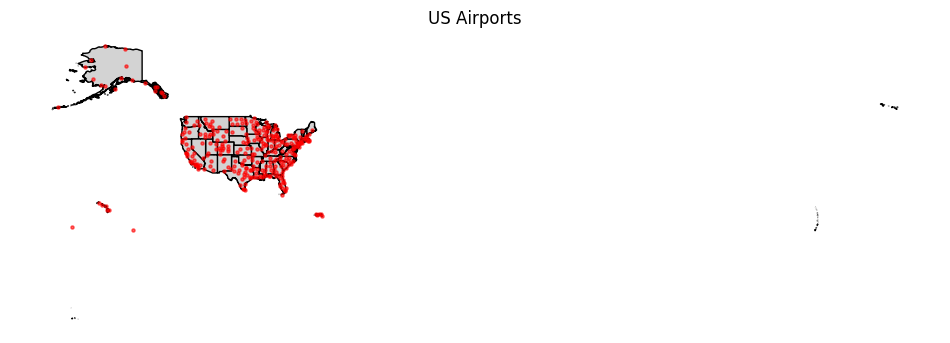

In [ ]:
# plot geo data

import tempfile
from pathlib import Path
import requests
import zipfile

tmpdir = Path(tempfile.mkdtemp(prefix="us_maps_"))
url = "https://www2.census.gov/geo/tiger/GENZ2025/shp/cb_2025_us_state_5m.zip"
r = requests.get(url, stream=True)
r.raise_for_status()
zip_path = tmpdir / "us_states.zip"
with open(zip_path, "wb") as f:
    for chunk in r.iter_content(chunk_size=8192):
        f.write(chunk)

with zipfile.ZipFile(zip_path, "r") as z:
    z.extractall(tmpdir)

shp_files = list(tmpdir.glob("*.shp"))
states_gdf = gpd.read_file(shp_files[0])
airports_gdf = gpd.GeoDataFrame(
    dfs_kv["airports.csv"],
    geometry=gpd.points_from_xy(
        dfs_kv["airports.csv"]["LONGITUDE"], 
        dfs_kv["airports.csv"]["LATITUDE"]
    ),
    crs="EPSG:4326"  # WGS84
)

# Plot: states + airports
fig, ax = plt.subplots(figsize=(12, 8))

# Plot states
states_gdf.plot(ax=ax, color="lightgray", edgecolor="black")

# Plot airports
airports_gdf.plot(ax=ax, color="red", markersize=5, alpha=0.6)

ax.set_title("US Airports")
ax.set_axis_off()
plt.show()

# Dataset description

- flights.csv
    - YEAR, MONTH, DAY, DAY_OF_WEEK: dates of the flight
    - AIRLINE: identify a unique airline
    - ORIGIN_AIRPORT_IATA_CODE and DESTINATION_AIRPORT_IATA_CODE: code attributed by IATA to identify the airports
    - SCHEDULED_DEPARTURE and SCHEDULED_ARRIVAL : scheduled times of take-off and landing
    - DEPARTURE_TIME and ARRIVAL_TIME: real times at which take-off and landing took place
    - DEPARTURE_DELAY and ARRIVAL_DELAY: difference (in minutes) between planned and real times
    - DISTANCE: distance (in miles)
    - CANCELLED: 1 if is deleted
    - CANCELLATION_REASON: if is cancelled, the reason code
    - SCHEDULED_TIME: estimated flight time
    - ELAPSED_TIME: effective flight time
    - AIR_TIME: effective on-air time
    - TAXI_OUT: time from the gate to lift-off
    - WHEELS_OFF: effective moment of lift-off
    - WHEELS_ON: effective moment of landing
    - DIVERTED: some reason flight get different landing
- airports.csv
    - AIRPORTS_IATA_CODE: unique identifier code
    - CITY STATE COUNTRY LATITUDE LONGITUDE : geo referencies
- airlines.csv
    . naming referencies (we can ignore it for data analisys)


# Data analisys
We used a representative sample to speedup the analisys

In [8]:
for k ,v in dfs_kv.items():
    print(f"Dataset: {k} - shape: {v.shape}")


Dataset: airlines.csv - shape: (14, 2)
Dataset: airports.csv - shape: (322, 7)
Dataset: flights.csv - shape: (5000, 31)


In [9]:
# remame columns to avoid name missmatch when merging
dfs_kv["airlines.csv"].rename( columns={"IATA_CODE": "AIRLINES_IATA_CODE"}, inplace=True )
dfs_kv["airports.csv"].rename( columns={"IATA_CODE": "AIRPORTS_IATA_CODE"}, inplace=True )
dfs_kv["flights.csv"].rename( columns={"AIRLINE": "AIRLINES_IATA_CODE"},  inplace=True )
dfs_kv["flights.csv"].rename( columns={"ORIGIN_AIRPORT": "ORIGIN_AIRPORT_IATA_CODE"}, inplace=True )
dfs_kv["flights.csv"].rename( columns={"DESTINATION_AIRPORT": "DESTINATION_AIRPORT_IATA_CODE"}, inplace=True )


- to be analized we have airports.csv and flights.csv that need to be merged
    - which is the best granularity to merge?

In [ ]:
# cast types flights.csv
dfs_kv['flights.csv']['ARRIVAL_DELAY'] = pd.to_numeric(dfs_kv['flights.csv']['ARRIVAL_DELAY'], errors='coerce') # convert into numeric
dfs_kv['flights.csv']['ORIGIN_AIRPORT_IATA_CODE'] = dfs_kv['flights.csv']['ORIGIN_AIRPORT_IATA_CODE'].astype('category') # category
dfs_kv['flights.csv']['DESTINATION_AIRPORT_IATA_CODE'] = dfs_kv['flights.csv']['DESTINATION_AIRPORT_IATA_CODE'].astype('category') # category
dfs_kv['flights.csv']['DATETIME'] = pd.to_datetime(dfs_kv['flights.csv'][['YEAR', 'MONTH', 'DAY']]) # datetime features
dfs_kv['flights.csv']['CANCELLED'] = dfs_kv['flights.csv']['CANCELLED'].astype(bool) # boolean
dfs_kv['flights.csv']['AIRLINES_IATA_CODE'] = dfs_kv['flights.csv']['AIRLINES_IATA_CODE'].astype('category') # category
# https://www.bts.gov/archive/publications/federal_register/2001/bts_20011227
BTS_MAP_CANCELLATION_REASON={"A": "Carrier", "B": "Weather", "C": "National Air System", "D": "Late Aircraft"}
dfs_kv['flights.csv']['CANCELLATION_REASON'] = dfs_kv['flights.csv']['CANCELLATION_REASON'].astype('category') # category


# cast types airports.csv
dfs_kv["airports.csv"]['CITY'] = dfs_kv["airports.csv"]['CITY'].astype('category') # category
dfs_kv["airports.csv"]['STATE'] = dfs_kv["airports.csv"]['STATE'].astype('category') # category
dfs_kv["airports.csv"]['COUNTRY'] = dfs_kv["airports.csv"]['COUNTRY'].astype('category') # category
dfs_kv["airports.csv"]['AIRPORTS_IATA_CODE'] = dfs_kv["airports.csv"]['AIRPORTS_IATA_CODE'].astype('category') # category



In [ ]:
# departure time filed cast
def format_hhmm(value:int|float|str) -> str :
    if not pd.isna(value):
        try:
            value = int(value)
        except:
            return pd.NA
        if value == 2400 :
            value = 0
        if   value < 0 or value > 2359 :
            return pd.NA
        value :str  = f"{value:04d}"
        if  int(value[:2]) > 23 or int(value[2:]) > 59 :
            return pd.NA
        hh = int(value[:2]); mm = int(value[2:])
        return datetime.time(hh, mm) # effective casting
    else:
        return pd.NA

dfs_kv['flights.csv']["SCHEDULED_DEPARTURE"] = dfs_kv['flights.csv']["SCHEDULED_DEPARTURE"].apply(format_hhmm)
dfs_kv['flights.csv']["DEPARTURE_TIME"] = dfs_kv['flights.csv']["DEPARTURE_TIME"].apply(format_hhmm)
dfs_kv['flights.csv']['SCHEDULED_ARRIVAL'] = dfs_kv['flights.csv']['SCHEDULED_ARRIVAL'].apply(format_hhmm)
dfs_kv['flights.csv']['ARRIVAL_TIME'] = dfs_kv['flights.csv']['ARRIVAL_TIME'].apply(format_hhmm)


to_delete = ['YEAR', 'MONTH', 'DAY', 'CANCELLED' ] # 'CANCELLED' is redundant with 'CANCELLATION_REASON' and the date is already represented in the 'DATETIME' column, so they can be dropped
dfs_kv['flights.csv'] = dfs_kv['flights.csv'].drop(columns=to_delete)

to_delete = ['AIRPORT','COUNTRY' ] # name and country have less information than city and state, so they can be dropped
dfs_kv['airports.csv'] = dfs_kv['airports.csv'].drop(columns=to_delete)


Now the dadatasets will be merged
Some missing values solution adding more data are tested,in non resolutive way

In [ ]:
flights_df = dfs_kv["flights.csv"].copy()



# standardize IATA codes (strip, upper case)
flights_df["ORIGIN_AIRPORT_IATA_CODE"] = (
    flights_df["ORIGIN_AIRPORT_IATA_CODE"].astype(str).str.strip().str.upper()
)
flights_df["DESTINATION_AIRPORT_IATA_CODE"] = (
    flights_df["DESTINATION_AIRPORT_IATA_CODE"].astype(str).str.strip().str.upper()
)
#--------------------------------------------

origin_airports = dfs_kv["airports.csv"].rename(
    columns={
        "AIRPORTS_IATA_CODE": "ORIGIN_AIRPORTS_IATA_CODE",
        "CITY": "ORIGIN_CITY",
        "STATE": "ORIGIN_STATE",
        "COUNTRY": "ORIGIN_COUNTRY",
        "LATITUDE": "ORIGIN_LATITUDE",
        "LONGITUDE": "ORIGIN_LONGITUDE"
    }
)

origin_airports["ORIGIN_AIRPORTS_IATA_CODE"] = (
    origin_airports["ORIGIN_AIRPORTS_IATA_CODE"].astype(str).str.strip().str.upper()
)

df = pd.merge(
    flights_df,
    origin_airports,
    left_on="ORIGIN_AIRPORT_IATA_CODE",
    right_on="ORIGIN_AIRPORTS_IATA_CODE",
    how="left"
)

destination_airports = dfs_kv["airports.csv"].rename(
    columns={
        "AIRPORTS_IATA_CODE": "DEST_AIRPORTS_IATA_CODE",
        "CITY": "DEST_CITY",
        "STATE": "DEST_STATE",
        "COUNTRY": "DEST_COUNTRY",
        "LATITUDE": "DEST_LATITUDE",
        "LONGITUDE": "DEST_LONGITUDE"
    }
)

destination_airports["DEST_AIRPORTS_IATA_CODE"] = (
    destination_airports["DEST_AIRPORTS_IATA_CODE"].astype(str).str.strip().str.upper()
)

df = pd.merge(
    df,
    destination_airports,
    left_on="DESTINATION_AIRPORT_IATA_CODE",
    right_on="DEST_AIRPORTS_IATA_CODE",
    how="left"
)

# recast into category
iata_code_cols = [
    "ORIGIN_AIRPORT_IATA_CODE",
    "DESTINATION_AIRPORT_IATA_CODE",
    "ORIGIN_AIRPORTS_IATA_CODE",
    "DEST_AIRPORTS_IATA_CODE",
]

for col in iata_code_cols:
    df[col] = df[col].astype("category")

The logic of the previous step was a simple join between the flights and airports datasets 
to add the flight data with the corresponding airport information (city, state, country, latitude, longitude)
for both origin and destination airports. This allows for more comprehensive analysis of flight delays 
by considering geographical and regional factors that may influence delays.

In [ ]:
to_delete = ['FLIGHT_NUMBER','TAIL_NUMBER'] # name and country have less information than city and state, so they can be dropped
df = df.drop(columns=to_delete)

In [ ]:
# create a single column calculating delays as sum of arrival 
# and departure delay, considering only non cancelled flights, nan if cancelled


def total_delay(row,):
    """
    Create a single column calculating delays as sum of arrival and departure delay
    Negative values are set to 0, and if the flight is cancelled 
    (CANCELLATION_REASON is not null or empty) the value is set to NA
    because of business logic (bad user experience)

    We have multiple reasons of delay:
    - Departure delay: the flight departs later than scheduled
    - Arrival delay: the flight arrives later than scheduled

    """
    arrival_delay = row['ARRIVAL_DELAY'] if row['ARRIVAL_DELAY'] > 0 else 0
    departure_delay = row['DEPARTURE_DELAY'] if row['DEPARTURE_DELAY'] > 0 else 0
    if pd.isna(row['CANCELLATION_REASON']) or not row['CANCELLATION_REASON']:
        return (arrival_delay + departure_delay) /2
    else:
        return pd.NA

df['TOTAL_DELAY'] = df.apply(total_delay, axis=1)


def max_delay_if_cancelled(row, max_delay):
    """
    If the flight is cancelled, set the delay max of the 
    TOTAL_DELAY column, a simple strategy to avoid infinite value
    we must evaluete the user disservice time
    This simplification should change the model result
    because of the 
    """
    if row['DIVERTED']:
        return max_delay
    elif pd.isna(row['CANCELLATION_REASON']) or not row['CANCELLATION_REASON']:
        return row['TOTAL_DELAY']
    else:
        return max_delay

# if the flight is cancelled, set the delay max of the TOTAL_DELAY column
max_delay = df['TOTAL_DELAY'].max()
df['TOTAL_DELAY'] = df.apply(max_delay_if_cancelled, axis=1, max_delay=max_delay)



The TOTAL_DELAY column is now ready for analysis,
and it can be used to evaluate the distribution of delays. 
It will be created and classificated focusing on user experience,
so that we can evaluate the disservice time for users.
The total delay is a sum of positive part of arrival and departure delay, 
and if the flight is cancelled the value is set to the maximum of the destruction time, 
only for the avoiding inifite values.

In [16]:
# in this scenario we ignore the time components of the various
# delay reasons focusing on the binary information 
# preparing for deleting this information

to_transform = ['DEPARTURE_DELAY','ARRIVAL_DELAY',
             'AIR_SYSTEM_DELAY' , 'WEATHER_DELAY', 
             'SECURITY_DELAY', 'AIRLINE_DELAY',
             'LATE_AIRCRAFT_DELAY'] 

df[to_transform] = df[to_transform] > 0 

In [ ]:
# delete timing component and over represented geographic features
to_delete = [
      'TAXI_OUT',
      'TAXI_IN',
      'WHEELS_OFF',
      'WHEELS_ON',
      'AIR_TIME',
      'SCHEDULED_TIME',
      'ELAPSED_TIME',
      'DEPARTURE_TIME',
      'DIVERTED',
      'SCHEDULED_ARRIVAL',
      'SCHEDULED_DEPARTURE',
      'DEPARTURE_DELAY',
      'ARRIVAL_DELAY',
      'ARRIVAL_TIME',
      'ORIGIN_AIRPORT_IATA_CODE',
      'DESTINATION_AIRPORT_IATA_CODE',
      #'ORIGIN_CITY',
      #'DEST_CITY',

      ] 
df = df.drop(columns=to_delete)




Some of the components of the dataset are over-represented, such as the geographic features 
(origin and destination airport) and the timing features (scheduled departure and arrival time, 
departure and arrival delay, etc.). And they are collapsed and transformed into binary features 
(e.g., whether there was a delay or not) to reduce the dimensionality and focusing on the most
relevant information for the analysis.

In [18]:
# drop informative leakage (component of total delay)
delay_components = [
    'AIR_SYSTEM_DELAY',
    'SECURITY_DELAY', 
    'AIRLINE_DELAY',
    'LATE_AIRCRAFT_DELAY',
    'WEATHER_DELAY'
]
df = df.drop(columns=delay_components)

Plot of various informations of the dataset in this step

In [19]:
df.info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   DAY_OF_WEEK                5000 non-null   int64         
 1   AIRLINES_IATA_CODE         5000 non-null   category      
 2   DISTANCE                   5000 non-null   int64         
 3   CANCELLATION_REASON        65 non-null     category      
 4   DATETIME                   5000 non-null   datetime64[us]
 5   ORIGIN_AIRPORTS_IATA_CODE  4532 non-null   category      
 6   ORIGIN_CITY                4532 non-null   category      
 7   ORIGIN_STATE               4532 non-null   category      
 8   ORIGIN_LATITUDE            4526 non-null   float64       
 9   ORIGIN_LONGITUDE           4526 non-null   float64       
 10  DEST_AIRPORTS_IATA_CODE    4532 non-null   category      
 11  DEST_CITY                  4532 non-null   category      
 12  DEST_STATE       

### evaluating more correlations methods

- Pearson’s Correlation measures for assessing how much two attributes, A and B, change together in a **linear normalized** space. 
    - χ² correlation allows measuring a relationship between **nominal** attributes
- Kendall’s Rank Correlation, measures the association between two **ordinal** attributes.
- Spearman’s Rank Correlation, assesses how well the relationship between two variables can be described using a **monotonic** function. 



#### **Reference Table**

| Correlation Type | Data Type Suitability | Relationship Type |
| :--- | :--- | :--- |
| **Pearson** | Ratio-scaled | **Linear** |
| **$\chi^2$ (Chi-squared)**| Nominal / Categorical| Independence/Association|
| **Kendall** | Ordinal, Interval, Ratio | **Ordinal association** |
| **Spearman** | Ordinal, Interval, Ratio | **Monotonic** |


Example

```py

def correlations_print(df, target:str , attributes:list ,methods='pearson',)
    from scipy.stats import spearmanr,kendalltau,pearsonr, pointbiserialr
    for attribute in attributes:
      df_no_na=df[[target, attribute]].dropna()
      if methods == 'pearson':
          fun = pearsonr
      else if methods == 'kendall':
          fun = kendalltau
      else if methods == 'spearman':
          fun = spearmanr
      else if methods == 'biserial':
          fun = pointbiserialr
      else:
          raise ValueError('Unsupported methods')
      if p_value>0.05:
          print(f'We cannot say anything about the correlation between {target} and {attribute}')
      r,p_value=fun(df_no_na[target], df_no_na[attribute])
      print(f"{methods} : Corr={r} , ℙ={p_value}")
      return r,p_value

```

In [ ]:
# method: Literal['pearson', 'kendall', 'spearman'] = "pearson"

corr_spearman = df.corr(method='spearman',numeric_only=True)


Thi is just for a having a quick look.

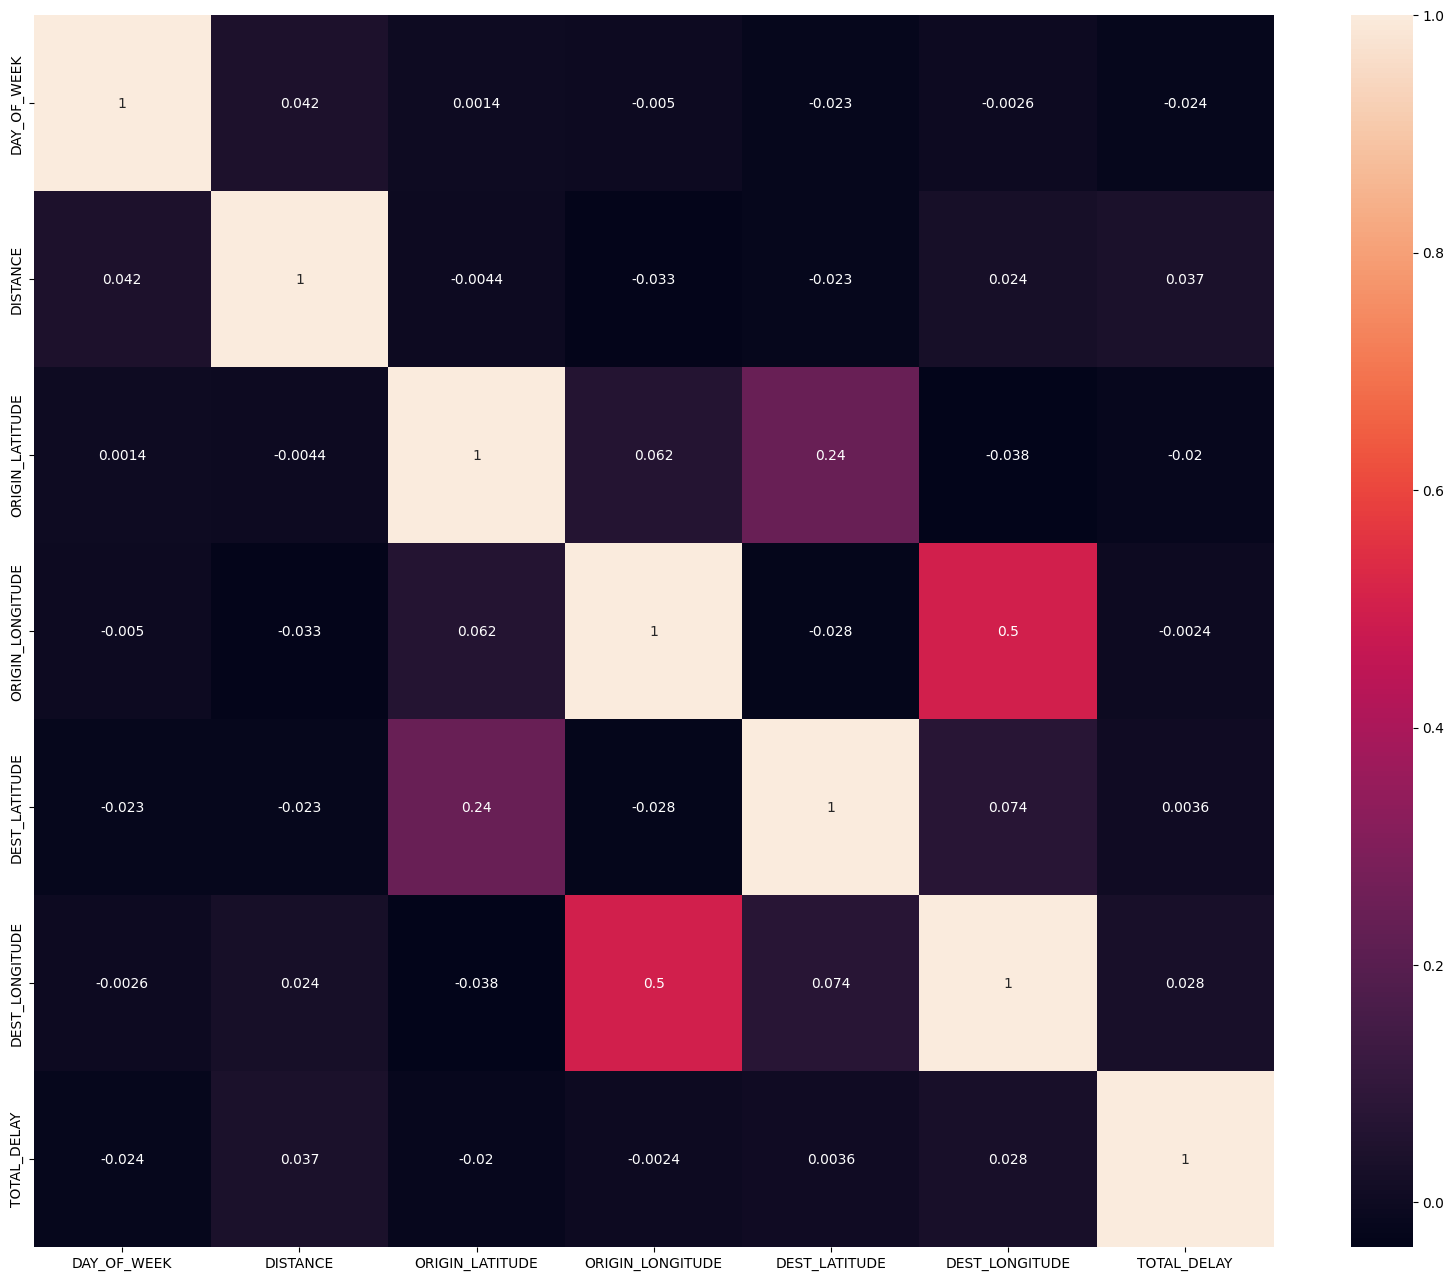

In [21]:
plt.figure(figsize=(20,16))
sns.heatmap(corr_spearman, annot=True);

On first eye after preprocessing the dataset, the most of the correlation is in geographical fields

### So we have some null values

In [22]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
DAY_OF_WEEK,5000.0,3.922,1.0,2.0,4.0,6.0,7.0,2.005173
DISTANCE,5000.0,828.8484,31.0,386.0,651.0,1067.0,4962.0,619.303294
DATETIME,5000,2015-07-05 00:39:10.080000,2015-01-01 00:00:00,2015-04-05 00:00:00,2015-07-08 00:00:00,2015-10-03 00:00:00,2015-12-31 00:00:00,NaN
ORIGIN_LATITUDE,4526.0,36.678793,13.48345,33.43417,37.36186,40.78839,71.28545,5.984378
ORIGIN_LONGITUDE,4526.0,-95.794923,-159.33896,-112.00806,-90.50754,-81.78202,-64.79856,18.048043
DEST_LATITUDE,4528.0,36.678075,18.33731,32.89595,37.197925,40.78839,66.88468,6.027646
DEST_LONGITUDE,4528.0,-95.17575,-162.59855,-106.60919,-90.25803,-81.31603,-64.97336,18.009394
TOTAL_DELAY,5000.0,47.042,0.0,0.0,0.0,15.0,1615.0,205.346362


# Value dispersion and central tendencies

## **METRICS:**

- Centrality: Mode, Median, Average (Mean)
- Dispersion: Standard Deviation, IQR, Entropy

---

**Formula (Mode):**
$$
\text{Mode} = \text{argmax}_x\; f(x)
$$
where $f(x)$ is the frequency of value $x$ in the dataset.

Interpretation:
- Tells which value/category is the most frequent.
- Useful especially for categorical variables.

Example:
- `AIRLINES_IATA_CODE` mode = `WN` means `WN` is the most frequent airline in the sample.
- If `WN` frequency is very high, the distribution is dominated by one category.

---

**Formula (ordered median):**
$$
\tilde{x} = x_{\left(\frac{n+1}{2}\right)}
$$

Interpretation:
- 50th percentile.
- 50% of observations are below or equal, 50% above or equal.
- Robust to outliers.

Example:
- `TOTAL_DELAY` median = 12 min means half of flights have delay $\le 12$ min and half $\ge 12$ min.

---

**Formula (Average / Mean):**
$$
\mathbb{E} = \bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i
$$

Interpretation:
- Arithmetic center.
- Sensitive to extreme values (outliers).

Example:
- `TOTAL_DELAY` mean = 95 min and median = 12 min suggests a right-skewed distribution with extreme delays.

---

**Formula (IQR):**
$$
IQR = Q_3 - Q_1
$$

Interpretation:
- Spread of the middle 50% of the data.
- Robust to outliers.
- Lower IQR = compact central distribution.

Example:
- `TOTAL_DELAY` with $Q_1=5$, $Q_3=25$ gives $IQR=20$ min (central delays fairly compact).
- If $Q_1=5$, $Q_3=120$, then $IQR=115$ min (central delays highly dispersed).

---

**Formula (Standard Deviation):**
$$
\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2}
$$

Interpretation:
- Average spread around the mean.
- $\sigma = 0$ only when all values are identical.
- Bigger $\sigma$ means more variability.

Example:
- `DISTANCE` std = 607 miles means routes vary a lot in flight distance.
- `std = 0` would mean every flight has exactly the same distance (practically impossible whith empirycal values).

---

**Formula (Normalized Shannon Entropy, nominal dispersion):**

$$
H_{\text{norm}}(χ)=\frac{-\sum_{i=1}^{k} p_i\log p_i}{\log k}
=\frac{\mathbb{E}[-\log f(χ)]}{\log k}
$$

Interpretation:
- Measures category balance (uncertainty/diversity).
- Range: $0 \le \mathcal{H}(χ) \le 1$

where $k$ is the number of categories.
- $\mathcal{H}=0$: one category has probability 1 (maximum concentration).
- If $H_{\text{norm}} > 0.5$, categories are not strongly dominated by one single class.
- $\mathcal{H}=1$: all categories equally likely (maximum dispersion).


---

Summary:
- Median and IQR are robust to outliers.
- Mean and standard deviation are sensitive to extreme values.
- Mode identifies the most frequent value.
- Entropy quantifies how balanced nominal categories are.

### Data tyoe analisys

| Feature                    | Type            | Metric(s)            | Note                                  |
|----------------------------|-----------------|----------------------|-------------------------------------- |
| DAY_OF_WEEK                | int64           | mode, entropy        | is a well balanced category?          |
| AIRLINES_IATA_CODE         | category        | mode, entropy        | is a well balanced category?          |
| DISTANCE                   | int64           | avg, std             | distances are the same for each fight?|
| CANCELLATION_REASON        | category        | mode, entropy        | is a well balanced category?          |
| DATETIME                   | datetime64[us]  | median, IQR          | is centered (time balanced)           |
| ORIGIN_AIRPORTS_IATA_CODE  | category        | mode, entropy        | is a well balanced category?          |
| ORIGIN_STATE               | category        | mode, entropy        | is a well balanced category?          |
| ORIGIN_LATITUDE            | float64         | median, std          | geographic centered?                  |
| ORIGIN_LONGITUDE           | float64         | median, std          | geographic centered?                  |
| DEST_AIRPORTS_IATA_CODE    | category        | mode, entropy        | is a well balanced category?          |
| DEST_STATE                 | category        | mode, entropy        | is a well balanced category?          |
| DEST_LATITUDE              | float64         | median, std          | geographic centered?                  |
| DEST_LONGITUDE             | float64         | median, std          | geographic centered?                  |
| TOTAL_DELAY                | float64         | avg, std             | distances are the same?               |

In [23]:

# median
for col in ['DEST_LATITUDE', 'DEST_LONGITUDE', 'DATETIME', 'ORIGIN_LATITUDE', 'ORIGIN_LONGITUDE']:
    print(f'Feature {col}: median {df[col].median()},')


# mode
for col in ['DAY_OF_WEEK',  'AIRLINES_IATA_CODE', 'CANCELLATION_REASON', 
            'ORIGIN_STATE', 'DEST_STATE','ORIGIN_AIRPORTS_IATA_CODE','DEST_AIRPORTS_IATA_CODE']: 
    print(f'Feature {col}: mode {df[col].mode()[0]}')


# average (mean)
for col in ['DISTANCE', 'TOTAL_DELAY']:
    print(f'Feature {col}: average {df[col].mean()}')


# standard deviation
for col in ['DISTANCE', 'TOTAL_DELAY']:
    print(f'Feature {col}:  std {df[col].std()}')

# IRQ
for col in ['DATETIME']:
    print(f'Feature {col} IQR: [{df[col].quantile(0.75) - df[col].quantile(0.25)}]')


# standard deviation
for col in set(df.columns).difference({'DISTANCE', 'TOTAL_DELAY','DATETIME','DAY_OF_WEEK' }) :
    if df[col].dtypes not in ['category'] :
        print(f'Feature {col}: std {df[col].std()}')

# entropy
for col in ['DAY_OF_WEEK',  'AIRLINES_IATA_CODE', 'CANCELLATION_REASON', 
            'ORIGIN_STATE', 'DEST_STATE','ORIGIN_AIRPORTS_IATA_CODE','DEST_AIRPORTS_IATA_CODE']: 
    counts = df[col].value_counts(normalize=True)
    k = counts.size
    h = entropy(counts, base=2) / np.log2(k) if k > 1 else 0.0
    print(f'Feature {col}: norm-entropy {h}')


Feature DEST_LATITUDE: median 37.197925,
Feature DEST_LONGITUDE: median -90.25803,
Feature DATETIME: median 2015-07-08 00:00:00,
Feature ORIGIN_LATITUDE: median 37.36186,
Feature ORIGIN_LONGITUDE: median -90.50754,
Feature DAY_OF_WEEK: mode 1
Feature AIRLINES_IATA_CODE: mode WN
Feature CANCELLATION_REASON: mode B
Feature ORIGIN_STATE: mode CA
Feature DEST_STATE: mode TX
Feature ORIGIN_AIRPORTS_IATA_CODE: mode ATL
Feature DEST_AIRPORTS_IATA_CODE: mode ATL
Feature DISTANCE: average 828.8484
Feature TOTAL_DELAY: average 47.042
Feature DISTANCE:  std 619.3032936545278
Feature TOTAL_DELAY:  std 205.3463621827578
Feature DATETIME IQR: [181 days 00:00:00]
Feature ORIGIN_LATITUDE: std 5.9843776166492555
Feature DEST_LATITUDE: std 6.02764623300204
Feature DEST_LONGITUDE: std 18.00939437420026
Feature ORIGIN_LONGITUDE: std 18.04804301699755
Feature DAY_OF_WEEK: norm-entropy 0.9990070896495397
Feature AIRLINES_IATA_CODE: norm-entropy 0.870104553625211
Feature CANCELLATION_REASON: norm-entropy 0.9

### Summary Table of Feature Statistics

Values from 2015 full data

Use `FAST_SAMPLE = True` for print the same values, but from a representative sample.

| Feature | Centrality | Dispersion |
| --- | --- | --- |
| DEST_LATITUDE | median: 37.36186 | std: 5.999284838478888 |
| DEST_LONGITUDE | median: -90.25803 | std: 18.156160098617175 |
| DATETIME | median: 2015-07-02 00:00:00 | IRQ: 178 days |
| ORIGIN_LATITUDE | median: 37.36186 | std: 5.999337769454153 |
| ORIGIN_LONGITUDE | median: -90.25803 | std: 18.15636845650565 |
| DAY_OF_WEEK | mode: 4 |  norm-entropy: 0.9987887782879895 |
| AIRLINES_IATA_CODE | mode: WN | norm-entropy: 0.8759055438284181 |
| CANCELLATION_REASON | mode: B | norm-entropy: 0.7179713227519325 |
| ORIGIN_STATE | mode: CA | norm-entropy: 0.8173161942675409 |
| DEST_STATE | mode: CA | norm-entropy: 0.8173077300646155 |
| ORIGIN_AIRPORTS_IATA_CODE | mode: ATL | norm-entropy: 0.7633658536885178 |
| DEST_AIRPORTS_IATA_CODE | mode: ATL | norm-entropy: 0.7633620270618159 |
| DISTANCE | average: 822.3564947305235 | std: 607.7842873170442 |
| TOTAL_DELAY | average: 95.18458109951764 | std: 528.6463055657218 |

### Some basic plots (sometimes binned) for summary statistics features

### Pandas binning methods
```py
from statlib import bining_example
```

Just a quinck look

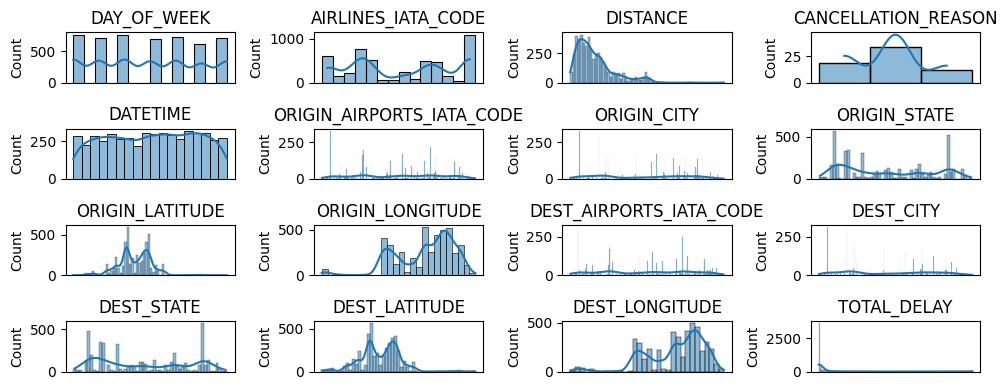

In [24]:
%reload_ext autoreload
from statlib.qq_plot import plot_numeric_grid, df_qqplot_easy, df_qqplot, dataframe_into_numeric, df_hist_compare

plot_numeric_grid(df, n_rows=4)

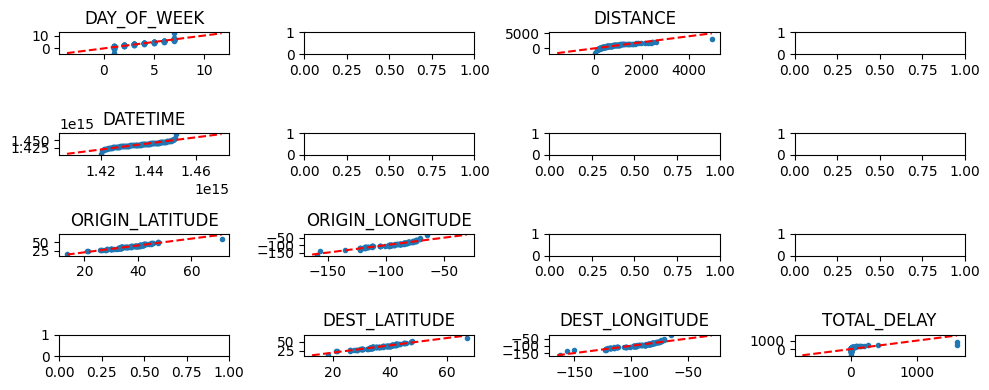

In [25]:
%reload_ext autoreload
# compared with normal distrib
df_qqplot_easy(dataframe_into_numeric(df), n_rows=4) # comparing with a normal distrib with the same mean and std
# empty values are skipped because of string-to-numeric value are not 
# yet perfectioned
# comparison are between distribution and a normal distribution

Details

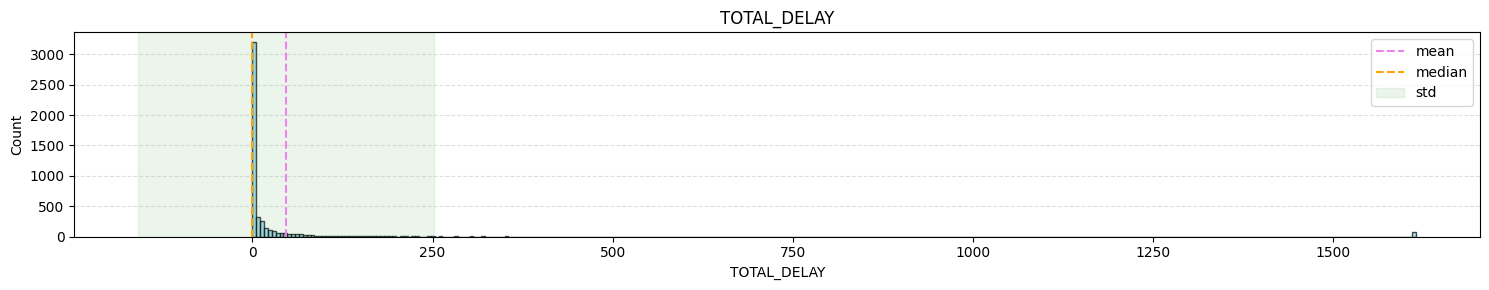

In [26]:
# -------------------------------------------------------------------
# target plots
# -------------------------------------------------------------------

col = 'TOTAL_DELAY'
s = df[col].dropna()
center = s.mean()
altern = s.median()
center_name = 'mean' 
altern_name = 'median'
std = s.std()

plt.figure(figsize=(15, 3))
plt.hist(  s, bins=300, color='skyblue', edgecolor='black',  alpha=0.7  )
plt.axvline(  center, color='violet',  linestyle='--', linewidth=1.5, label=center_name )
plt.axvline(  altern, color='orange',  linestyle='--', linewidth=1.5, label=altern_name )
plt.axvspan( center - std, center + std, color='green', alpha=0.08, label='std' )
plt.title(f'{col}')
plt.xlabel(col)
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()



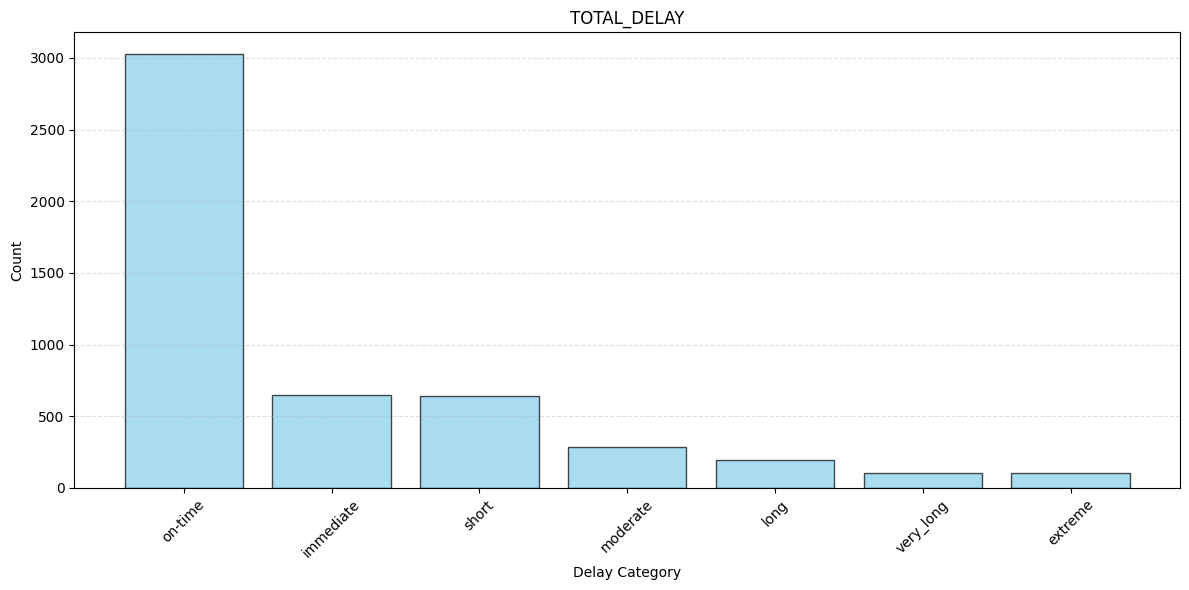


--- Statistics by Delay Category ---
on-time     :   3029 flights ( 60.6%)
immediate   :    646 flights ( 12.9%)
short       :    643 flights ( 12.9%)
moderate    :    284 flights (  5.7%)
long        :    193 flights (  3.9%)
very_long   :    102 flights (  2.0%)
extreme     :    103 flights (  2.1%)


In [27]:
# -------------------------------------------------------------------
# target plots - binned for best understanding, just a quick maual binning
# -------------------------------------------------------------------

col = 'TOTAL_DELAY'

# Bin definitions
bins = [0,4, 14, 49, 99, 199, 399, float('inf')]
labels = ['on-time','immediate','short', 'moderate', 'long', 'very_long', 'extreme']

# Add a new column grouping the delays into 
# categories based on domain knowledge 
# for certain analyses and visualizations.
df_bin = df.copy()
df_bin['GROUPED_DELAY'] = pd.cut(df_bin['TOTAL_DELAY'], bins=bins, labels=labels, right=False)

plt.figure(figsize=(12, 6))

category_counts = df_bin['GROUPED_DELAY'].value_counts()
category_counts = category_counts.reindex(labels)  # mantieni l'ordine originale

bars = plt.bar(category_counts.index, category_counts.values,  color='skyblue', edgecolor='black', alpha=0.7)

plt.title(f'{col}')
plt.xlabel('Delay Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

# print percentage
total = len(df_bin['GROUPED_DELAY'].dropna())
print("\n--- Statistics by Delay Category ---")
for label in labels:
    mask = df_bin['GROUPED_DELAY'] == label
    count = mask.sum()
    percentage = (count / total) * 100
    print(f"{label:12}: {count:6} flights ({percentage:5.1f}%)")

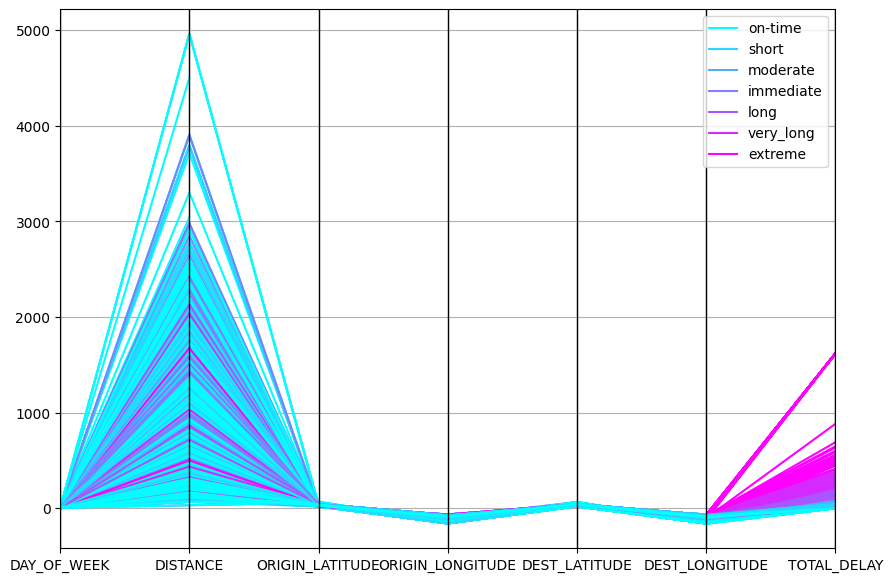

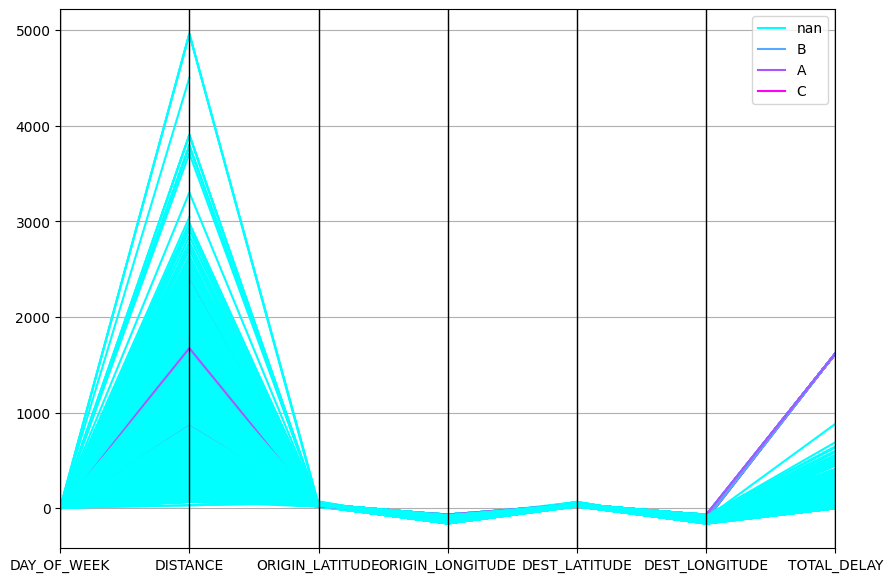

In [28]:
# quick random look for undestanding which class is more affected by a feature
from pandas.plotting import parallel_coordinates

class_column = "GROUPED_DELAY"
if FAST_SAMPLE:
    df_sample = df_bin
else:
    df_sample=df_bin[df_bin[class_column].notna()].sample(n=SAMPLE_SIZE, random_state=GLOBAL_SEED)
plt.figure(figsize=(10,7));
numeric_cols = df_sample.select_dtypes(include=[np.number]).columns
class_column = "GROUPED_DELAY"
plotting_col = list(numeric_cols) + [class_column]
parallel_coordinates(df_sample[plotting_col], class_column=class_column,colormap='cool');


# quick random look for undestanding which class is more affected by a feature

class_column = "CANCELLATION_REASON"
if FAST_SAMPLE:
    df_sample = df_bin
else:
    df_sample=df_bin[df_bin[class_column].notna()].sample(n=SAMPLE_SIZE, random_state=GLOBAL_SEED)
plt.figure(figsize=(10,7));
numeric_cols = df_sample.select_dtypes(include=[np.number]).columns
plotting_col = list(numeric_cols) + [class_column]
parallel_coordinates(df_sample[plotting_col], class_column=class_column,colormap='cool');

Short distance are related to low delay, they also having a very-low cancellation rate.

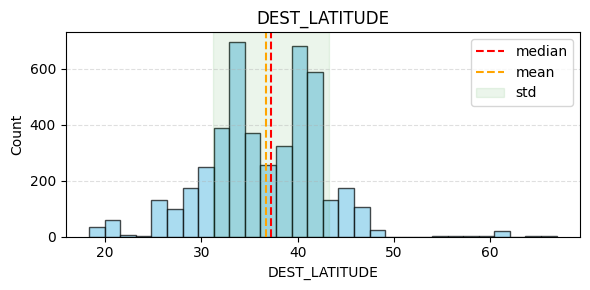

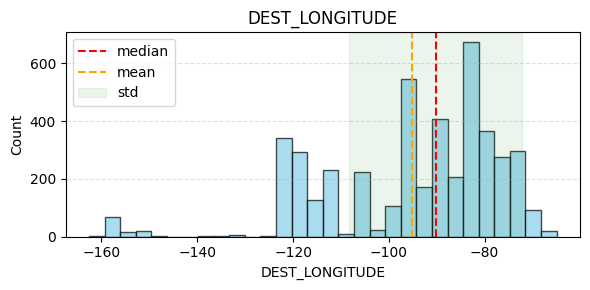

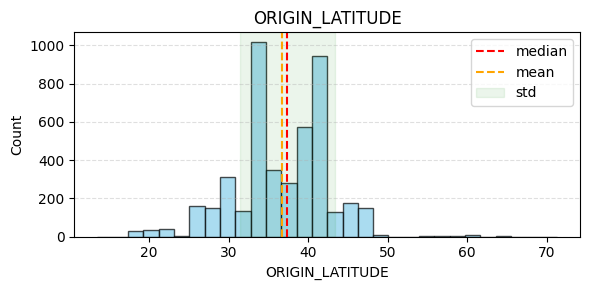

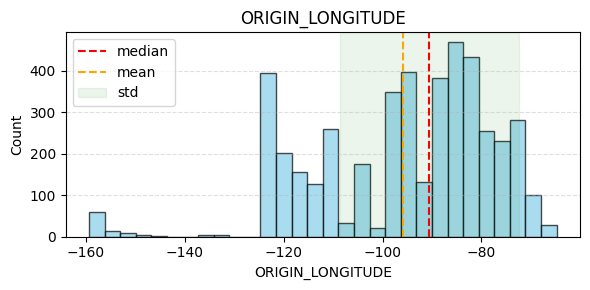

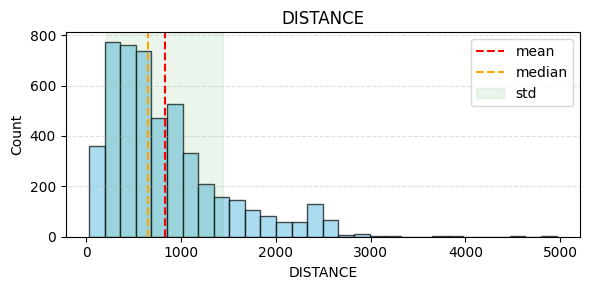

In [29]:
median_std = [
    'DEST_LATITUDE',
    'DEST_LONGITUDE',
    'ORIGIN_LATITUDE',
    'ORIGIN_LONGITUDE',
    #'TOTAL_DELAY'
]

mean_std = [
    'DISTANCE',
    #'TOTAL_DELAY'
]

# -------------------------------------------------------------------
# continuous plots
# -------------------------------------------------------------------
for col in median_std + mean_std:
    s = df[col].dropna()
    center = s.median() if col in median_std else s.mean()
    altern = s.median() if not col in median_std else s.mean()
    center_name = 'median' if col in median_std else 'mean'
    altern_name = 'median' if not col in median_std else 'mean'
    std = s.std()
    plt.figure(figsize=(6, 3))
    plt.hist(  s, bins=30, color='skyblue', edgecolor='black',  alpha=0.7  )
    plt.axvline(  center, color='red',  linestyle='--', linewidth=1.5, label=center_name )
    plt.axvline(  altern, color='orange',  linestyle='--', linewidth=1.5, label=altern_name )
    plt.axvspan(center - std,center + std,color='green',alpha=0.08,label='std' )
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.4)
    plt.legend()
    plt.tight_layout()
    plt.show()


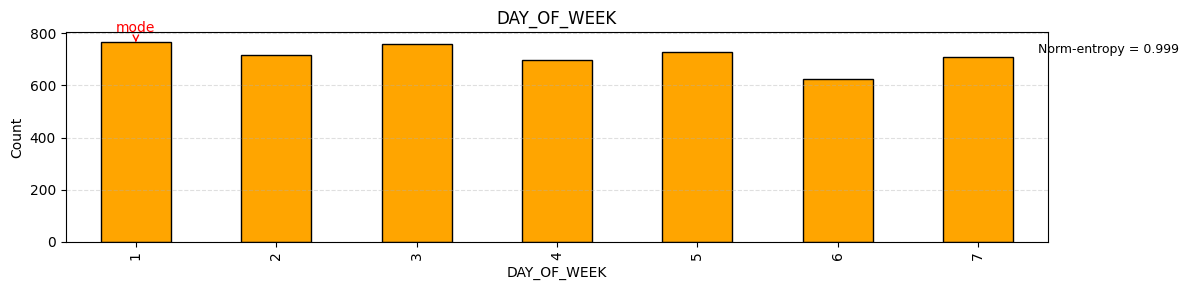

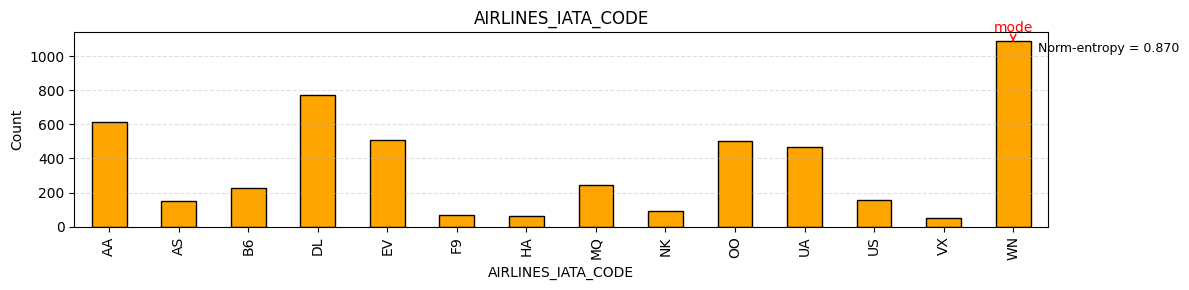

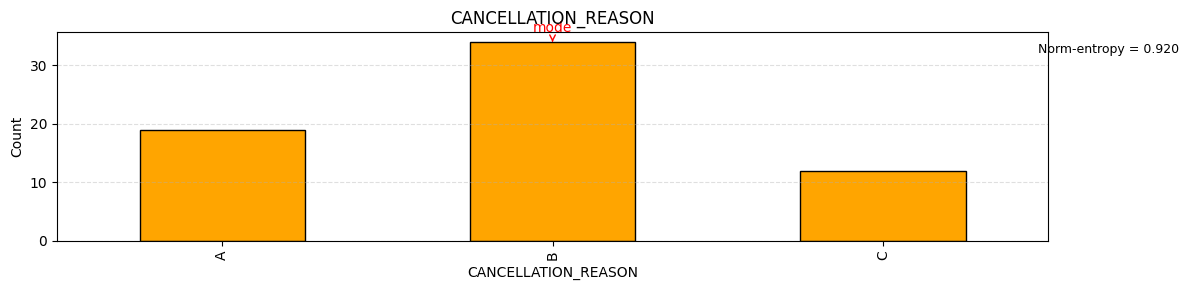

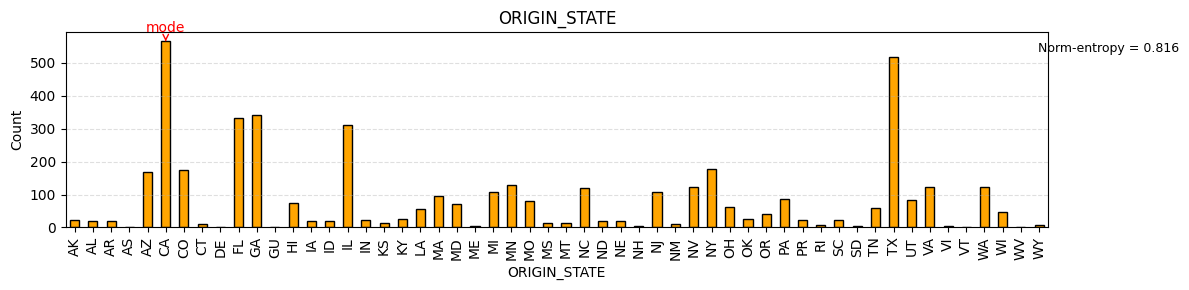

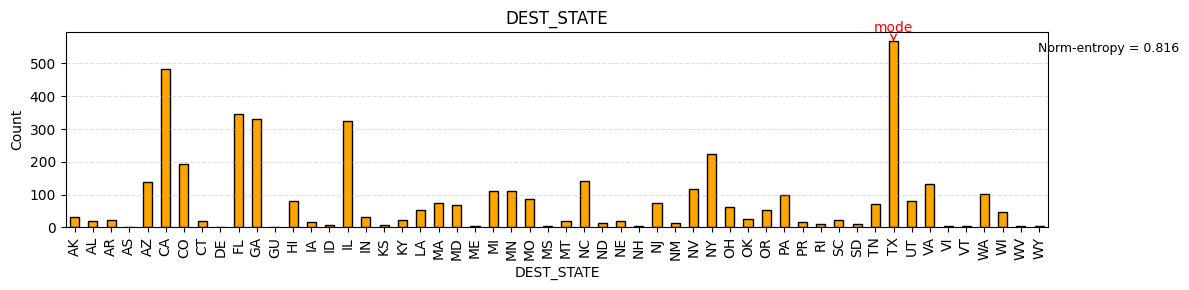

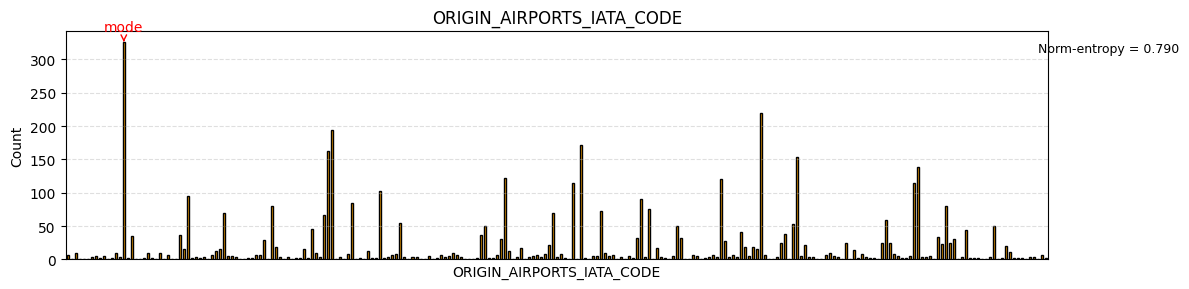

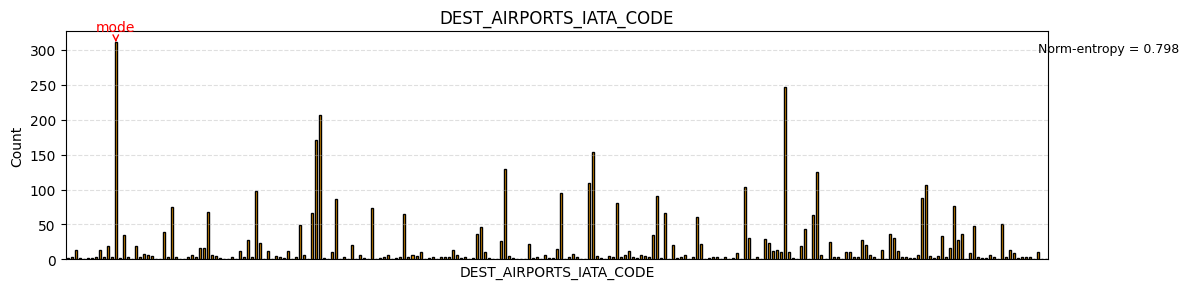

In [30]:
# -------------------------------------------------------------------
# categorical plots
# -------------------------------------------------------------------

cat_features = [
    'DAY_OF_WEEK',
    'AIRLINES_IATA_CODE',
    'CANCELLATION_REASON',
    'ORIGIN_STATE',
    'DEST_STATE',
    'ORIGIN_AIRPORTS_IATA_CODE',
    'DEST_AIRPORTS_IATA_CODE'
]

for col in cat_features: 
    vc = df[col].value_counts().sort_index()
    mode = df[col].mode()[0]
    p = vc / vc.sum()
    h = entropy(p, base=2) / np.log2(len(p)) if len(p) > 1 else 0
    plt.figure(figsize=(12, 3))
    ax = vc.plot( kind='bar', color='orange',  edgecolor='black'  )

    if mode in vc.index:
        i = list(vc.index).index(mode)
        ax.annotate( 'mode',xy=(i, vc.iloc[i]),xytext=(i, vc.iloc[i] * 1.05),ha='center',color='red',arrowprops=dict( arrowstyle='->',  color='red' ) )

    plt.text( 0.99, 0.95,  f'Norm-entropy = {h:.3f}',  transform=ax.transAxes, ha='left',  va='top',  fontsize=9  )
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    if  len(df[col].unique()) > 100 : # cleaning label for better visualization
        ax.set_xticks([])

    plt.grid(axis='y', linestyle='--', alpha=0.4)

    plt.tight_layout()
    plt.show()

## This should be a time series (Actually based on 2015 y)
We can ignore this series for now

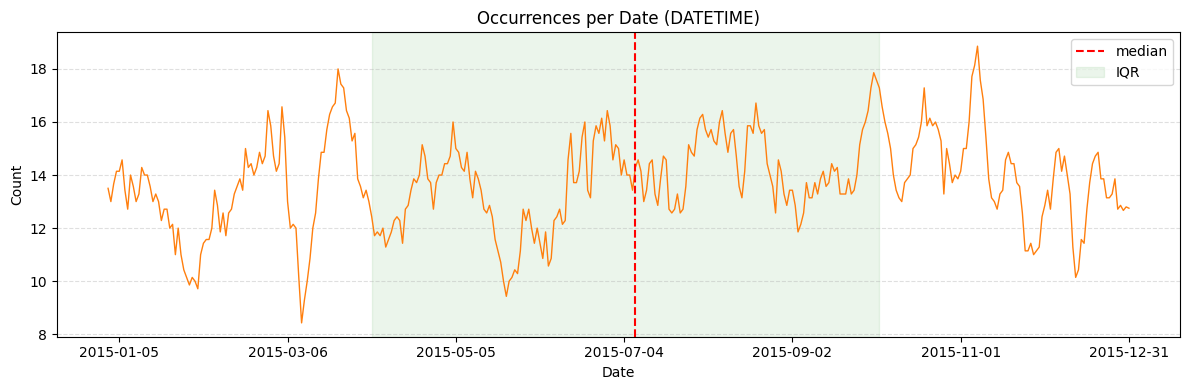

In [31]:

# -------------------------------------------------------------------
# datetime plot
# -------------------------------------------------------------------

dates = df['DATETIME'].dropna()
counts = dates.dt.date.value_counts().sort_index()
median_date = dates.median()
q25 = dates.quantile(0.25)
q75 = dates.quantile(0.75)

smooth = (pd.Series(counts.values, index=counts.index).rolling(7, center=True, min_periods=1).mean() )

plt.figure(figsize=(12, 4))
# plt.plot(  counts.index,  counts.values,  linewidth=0.8,  color='#1f77b4',  alpha=0.9 )

plt.plot( smooth.index,   smooth.values,  color='#ff7f0e',  linewidth=1 )
plt.axvline(     median_date.date(),     color='red',     linestyle='--',     linewidth=1.5,     label='median' )
plt.gca().axvspan( mdates.date2num(q25.date()), mdates.date2num(q75.date()), color='green', alpha=0.08, label='IQR' )
plt.title('Occurrences per Date (DATETIME)')
plt.xlabel('Date')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.gca().xaxis.set_major_locator(plt.MaxNLocator(8))
plt.legend()
plt.tight_layout()
plt.show()


# Missing values analysis

In [32]:
df_full['flights.csv'].info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 31 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   YEAR                 5819079 non-null  int64  
 1   MONTH                5819079 non-null  int64  
 2   DAY                  5819079 non-null  int64  
 3   DAY_OF_WEEK          5819079 non-null  int64  
 4   AIRLINE              5819079 non-null  string 
 5   FLIGHT_NUMBER        5819079 non-null  int64  
 6   TAIL_NUMBER          5804358 non-null  string 
 7   ORIGIN_AIRPORT       5819079 non-null  string 
 8   DESTINATION_AIRPORT  5819079 non-null  string 
 9   SCHEDULED_DEPARTURE  5819079 non-null  int64  
 10  DEPARTURE_TIME       5732926 non-null  float64
 11  DEPARTURE_DELAY      5732926 non-null  float64
 12  TAXI_OUT             5730032 non-null  float64
 13  WHEELS_OFF           5730032 non-null  float64
 14  SCHEDULED_TIME       5819073 non-null  float64
 15  ELAPSED_T

In [33]:
# the sample should have 5000 elements
# but we have near near 10% of missing values 

# the expected number of missing values is
# near 
df.info(show_counts=True)


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   DAY_OF_WEEK                5000 non-null   int64         
 1   AIRLINES_IATA_CODE         5000 non-null   category      
 2   DISTANCE                   5000 non-null   int64         
 3   CANCELLATION_REASON        65 non-null     category      
 4   DATETIME                   5000 non-null   datetime64[us]
 5   ORIGIN_AIRPORTS_IATA_CODE  4532 non-null   category      
 6   ORIGIN_CITY                4532 non-null   category      
 7   ORIGIN_STATE               4532 non-null   category      
 8   ORIGIN_LATITUDE            4526 non-null   float64       
 9   ORIGIN_LONGITUDE           4526 non-null   float64       
 10  DEST_AIRPORTS_IATA_CODE    4532 non-null   category      
 11  DEST_CITY                  4532 non-null   category      
 12  DEST_STATE       

In [34]:
df_full['airports.csv'].info(show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype   
---  ------              --------------  -----   
 0   AIRPORTS_IATA_CODE  322 non-null    category
 1   AIRPORT             322 non-null    string  
 2   CITY                322 non-null    category
 3   STATE               322 non-null    category
 4   COUNTRY             322 non-null    category
 5   LATITUDE            319 non-null    float64 
 6   LONGITUDE           319 non-null    float64 
dtypes: category(4), float64(2), string(1)
memory usage: 17.0 KB


In [35]:
# join process influence this value?
# key without match (origin)
flights_keys = set(dfs_kv["flights.csv"]["ORIGIN_AIRPORT_IATA_CODE"].dropna().astype(str).str.strip().str.upper().unique())
airports_keys = set(dfs_kv["airports.csv"]["AIRPORTS_IATA_CODE"].dropna().astype(str).str.strip().str.upper().unique())

missing_in_airports = sorted(flights_keys - airports_keys)
print("Origin code in flights but not in airports:", len(missing_in_airports))
print(missing_in_airports[:20])
missing_in_flights = sorted(airports_keys - flights_keys)
print("Origin code in airports but not in flights:", len(missing_in_flights))
print(missing_in_flights[:20])

Origin code in flights but not in airports: 114
['10135', '10140', '10141', '10146', '10257', '10268', '10299', '10397', '10423', '10469', '10529', '10599', '10693', '10721', '10779', '10781', '10792', '10800', '10821', '10849']
Origin code in airports but not in flights: 77
['ABY', 'ACT', 'ADK', 'ADQ', 'AKN', 'APN', 'BET', 'BGR', 'BLI', 'BQN', 'BTM', 'BTV', 'CDC', 'CIU', 'CLD', 'CMX', 'CNY', 'COU', 'CRW', 'DAB']


In [36]:
# the join process seem dows not have any influence, dataset has this shape 
f = dfs_kv["flights.csv"]["ORIGIN_AIRPORT_IATA_CODE"].astype(str).str.strip().str.upper()
print("Tot ORIGIN unique:", f.nunique())
print("IATA-like (3 letters):", f.str.fullmatch(r"[A-Z]{3}").sum())
print("Numeric:", f.str.fullmatch(r"\d+").sum())

Tot ORIGIN unique: 359
IATA-like (3 letters): 4532
Numeric: 468


Whe can try to estimate missing values instead of load new data (see the merge commented parts)
Can we have a correct estimation of airport IATA code using other values?

# Handling Missing Values

## Missingness Mechanisms (Context)
- **MCAR**: Missing completely at random → Deletion is safe.
- **MAR**: Missing depends on *observed* data → Imputation recommended.
- **MNAR**: Missing depends on *unobserved* data or the missing values themselves → Requires domain-aware modeling; deletion/imputation may bias results.

---

## Deletion Techniques
- **Listwise**: Drops entire rows containing any missing value.
  ```python
  df.dropna(axis=0, how='any')
  ```
- **Column-wise**: Drops columns with excessive missingness.
  ```python
  df.dropna(axis=1, how='any')
  ```
- **Pairwise**: Excludes missing values only for specific calculations/columns, preserving sample size elsewhere.
  ```python
  df.dropna(subset=['col1', 'col2'])
  ```

---

## Univariate Imputation Techniques
- **Fixed Value**: Replace with a constant (e.g., `"Unknown"`). Best for MCAR.
  ```python
  df.fillna(value="Unknown")
  ```
- **Min/Max**: Use column boundaries (useful for saturated sensors).
  ```python
  df['col'].fillna(df['col'].min())
  ```
- **Central Tendencies**: Mean, median, or mode. Handle outliers first if using mean.
  ```python
  df['col'].fillna(df['col'].mean())
  df['col'].fillna(df['col'].median())
  df['col'].fillna(df['col'].mode()[0])
  ```
- **Forward/Backward Fill**: Propagate previous/next values. Ideal for panel/time-series data.
  ```python
  df['col'].ffill()
  df['col'].bfill()
  ```
- **Interpolation**: Estimate missing points using neighboring values (`linear`, `quadratic`, `time`). Requires sorted data.
  ```python
  df.interpolate(method='linear')
  ```

---

## Multivariate / Advanced Imputation (`scikit-learn`)
- **Iterative Imputer** (MICE-like): Predicts missing values feature-by-feature using regression (default: Bayesian Ridge). Preserves inter-feature relationships.
  ```python
  from sklearn.impute import IterativeImputer
  imputer = IterativeImputer(random_state=0)
  df_imp = imputer.fit_transform(df)
  ```
- **KNN Imputer**: Fills missing values based on `k` nearest neighbors' values using robust distance metrics.
  ```python
  from sklearn.impute import KNNImputer
  imputer = KNNImputer(n_neighbors=5)
  df_imp = imputer.fit_transform(df)
  ```
- **Multiple Imputation**: Creates several imputed datasets to account for uncertainty, then aggregates results.
  ```python
  imputer = IterativeImputer(sample_posterior=True, random_state=42)
  df_imp = imputer.fit_transform(df)
  ```

---

## Evaluating Imputation Quality
1. **Distribution Preservation**: Compare original vs. imputed distributions visually or via KL/Wasserstein distance.
2. **Relationship Preservation**: Compute pairwise correlations before & after imputation; ensure no structural distortion.
3. **Statistical Testing**: Use `t-test`/`Mann-Whitney` (numerical) or `Pearson`/`Cramér's V` (categorical) to check if missingness mechanism aligns with assumptions (MCAR vs MAR).
4. **Consistency**: Avoid mixing incompatible data types during imputation; verify no spurious patterns were introduced.

> **Rule notes**: Use deletion only for MCAR or highly sparse irrelevant columns/rows. Prefer multivariate imputation for MAR/MNAR to preserve statistical power and feature relationships.

# Multivariate imputer

In [37]:

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler


df_numeric,metadata = generic_df_into_numeric_and_rollback(df)


COMPARE = False
if COMPARE:
    scalers = [MinMaxScaler(), StandardScaler(), RobustScaler()]
    scaler_names = ['MinMaxScaler', 'StandardScaler', 'RobustScaler']
else:
    scalers = [ StandardScaler()]
    scaler_names = [ 'StandardScaler']
scaled_result = {}

#for scaler, name in zip(scalers, scaler_names):
#    # Apply each scaler to your data
#    vect = scaler.fit_transform(df_numeric)
#    scaled_result[name] = pd.DataFrame(vect, columns=df_numeric.columns, index=df_numeric.index)

In [38]:
def compare_plot_numeric_grid(df, comp:list, n_rows=1, n_cols=None, figsize=(10, 6), ):
    import seaborn as sns
    import numpy as np
    import matplotlib.pyplot as plt
    if n_cols is None:
        n_cols = int(np.ceil( len(df.columns) // n_rows))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False, sharey=False)



    ## base
    for ax, col in zip(axes.flatten(), df.columns):
        sns.histplot(data=df, x=col, kde=True, ax=ax, fill=True, color="C0", alpha=0.35)

    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize, squeeze=False, sharey=False)

    palette = {
        "MinMaxScaler": "tab:grey",
        "StandardScaler": "tab:orange",
        "RobustScaler": "tab:purple",
    }

    # compare
    for name, df_c in comp.items():
        for ax, col in zip(axes.flatten(), df_c.columns):
            sns.histplot(data=df_c, x=col, ax=ax, fill=True, label=name, alpha=0.8 , color=palette[name])

    for ax, col in zip(axes.flatten(), df.columns):
        ax.set_title(col)
        ax.set_xlabel("")
        ax.set_xticks([])


    plt.tight_layout()
    plt.show()

#compare_plot_numeric_grid(df_numeric,scaled_result,n_rows=4)

Then we keep the Standard scaler

In [39]:
from sklearn.pipeline import Pipeline
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.impute import KNNImputer


scaler = StandardScaler()

imputer = KNNImputer()

pipe = Pipeline([
                #('scaler', scaler),
                ('imputer', imputer)
                ])
mtr_imputed = pipe.fit_transform(df_numeric)
df_imputed_knn = pd.DataFrame(mtr_imputed, columns=df_numeric.columns, index=df_numeric.index)

In [40]:
imputer = IterativeImputer()
pipe = Pipeline([
                #('scaler', scaler),
                ('imputer', imputer)
                ])
mtr_imputed = pipe.fit_transform(df_numeric)
df_imputed_iterative = pd.DataFrame(mtr_imputed, columns=df_numeric.columns, index=df_numeric.index)

Actually we need to reconstruct the dataset like below

```   
 7   ORIGIN_LATITUDE            4526 non-null   float64       
 8   ORIGIN_LONGITUDE           4526 non-null   float64           
 11  DEST_LATITUDE              4528 non-null   float64       
 12  DEST_LONGITUDE             4528 non-null   float64       

```
And a not normalized dataset?

# Restore original values

In [41]:
from pandas import (
    CategoricalDtype,
)

from pandas.api.types import (
    is_datetime64_any_dtype,
)

def infer_datetime_unit(values):

    a = np.asarray(values, dtype="float64")
    a = a[np.isfinite(a)]
    if a.size == 0:
        return "ns"
    m = np.nanmedian(np.abs(a))
    if m > 1e17:
        return "ns"
    if m > 1e14:
        return "us"
    if m > 1e11:
        return "ms"
    return "s"

def restore_dtypes_from_reference(df_num_imputed, df_reference):
    out = pd.DataFrame(index=df_num_imputed.index)

    for col in df_reference.columns:
        s_ref = df_reference[col]   
        x = df_num_imputed[col]
        dtype = s_ref.dtype

        # CATEGORY: remap
        if isinstance(dtype, CategoricalDtype):
            cats = s_ref.cat.categories
            ordered = s_ref.cat.ordered

            codes = pd.Series(np.rint(x), index=x.index).astype("Int64")
            valid = codes.notna() & (codes >= 0) & (codes < len(cats))
            codes = codes.where(valid, other=-1).astype("int64")

            out[col] = pd.Categorical.from_codes(
                codes, categories=cats, ordered=ordered
            )

        # DATETIME: 
        elif is_datetime64_any_dtype(dtype): 
            unit = infer_datetime_unit(x.values)
            vals = pd.Series(np.rint(x), index=x.index).astype("Int64")
            dt = pd.to_datetime(vals, unit=unit, errors="coerce")
            try:
                dt = dt.astype(dtype)   # es. datetime64[us]
            except Exception:
                pass
            out[col] = dt

        # INT
        elif  np.issubdtype(dtype, np.integer):
            vals = np.rint(x)
            if s_ref.isna().any():
                out[col] = pd.Series(vals, index=x.index).astype("Int64")
            else:
                out[col] = vals.astype(dtype)

        # BOOLEAN
        elif isinstance(dtype, pd.BooleanDtype) or np.issubdtype(dtype, np.bool_):
            out[col] = (x >= 0.5)

        # FLOAT as is
        elif isinstance(dtype, pd.Float64Dtype) or np.issubdtype(dtype, np.floating):
            out[col] = x.astype(dtype)

        # fallback
        else:
            out[col] = x

    return out


df_restored_knn = restore_dtypes_from_reference(df_imputed_knn, df_numeric)
df_restored_iterative = restore_dtypes_from_reference(df_imputed_iterative, df_numeric)

restore original values with imputed directy into original dataset

In [42]:
imputed_fiels = [ 'ORIGIN_AIRPORTS_IATA_CODE', 
                  'ORIGIN_STATE',
                  'ORIGIN_LATITUDE',
                  'ORIGIN_LONGITUDE',
                  'ORIGIN_CITY',
                  'DEST_AIRPORTS_IATA_CODE',
                  'DEST_STATE',
                  'DEST_LATITUDE',
                  'DEST_LONGITUDE',
                  'DEST_CITY',
                 ]

df_imputed_oring_knn = df.copy()
df_imputed_oring_iterative = df.copy()
for i in imputed_fiels:
    df_imputed_oring_knn[i] = df_restored_knn[i]
    df_imputed_oring_iterative[i] = df_restored_iterative[i]



# delete temporary df
#del df_imputed, df_restored, df_numeric

Do the data remain consistent?

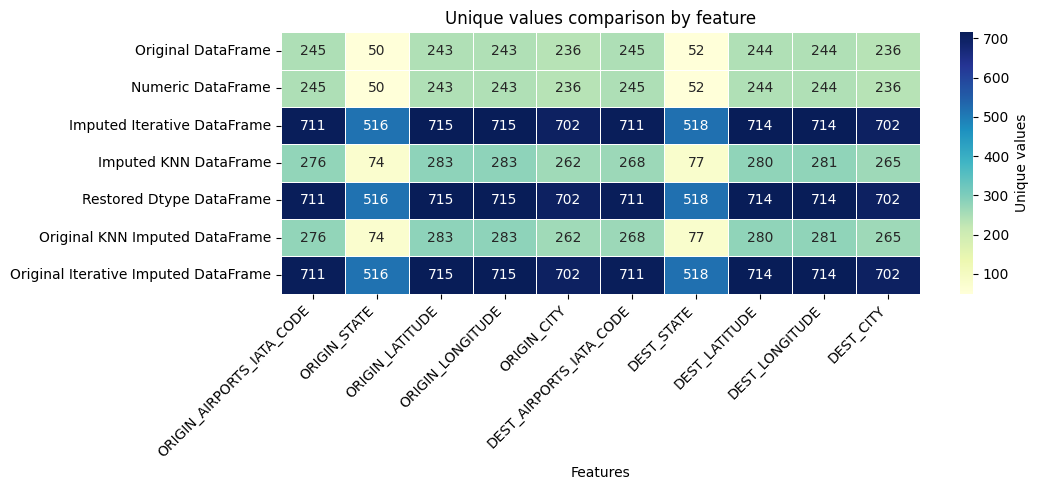

In [43]:
df_dict={
    "Original DataFrame": df,
    "Numeric DataFrame": df_numeric,
    "Imputed Iterative DataFrame": df_imputed_iterative,
    "Imputed KNN DataFrame": df_imputed_knn,
    "Restored Dtype DataFrame": df_restored_knn,
    "Original KNN Imputed DataFrame": df_imputed_oring_knn,
    "Restored Dtype DataFrame": df_restored_iterative,
    "Original Iterative Imputed DataFrame": df_imputed_oring_iterative,
}

def build_unique_count_table(df_dict, features):
    rows = []
    for title, df_curr in df_dict.items():
        row = {"DataFrame": title}
        for feat in features:
            # robust if a feature is missing in one dataframe
            row[feat] = df_curr[feat].nunique(dropna=True) if feat in df_curr.columns else np.nan
        rows.append(row)

    comp = pd.DataFrame(rows).set_index("DataFrame")
    return comp


def plot_unique_count_compare(df_dict, features, mode="heatmap"):
    comp = build_unique_count_table(df_dict, features)

    if mode == "heatmap":
        plt.figure(figsize=(max(10, len(features) * 1.1), 5))
        sns.heatmap(
            comp,
            annot=True,
            fmt=".0f",
            cmap="YlGnBu",
            linewidths=0.5,
            cbar_kws={"label": "Unique values"}
        )
        plt.title("Unique values comparison by feature")
        plt.xlabel("Features")
        plt.ylabel("")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    elif mode == "bar":
        # long format -> grouped bar chart
        comp_long = comp.reset_index().melt(
            id_vars="DataFrame",
            var_name="Feature",
            value_name="Unique values"
        )
        plt.figure(figsize=(max(12, len(features) * 1.4), 6))
        sns.barplot(
            data=comp_long,
            x="Feature",
            y="Unique values",
            hue="DataFrame"
        )
        plt.title("Unique values comparison by feature")
        plt.xticks(rotation=45, ha="right")
        plt.tight_layout()
        plt.show()

    else:
        raise ValueError("mode must be 'heatmap' or 'bar'")

    return comp


# -------------------------------------------------------------------
# usage
# -------------------------------------------------------------------

comparison_table = plot_unique_count_compare(df_dict, imputed_fiels, mode="heatmap")
#display(comparison_table)

# jupyter built-in function return the table
# like 
#   %time and %%time
#   %whos
#   %matplotlib inline
#   %reset -f

# comparing imputed with original

As we seen before, KNN is best solution for out dataset, but they are not a solution, because we know taht USA has only 50 states. So  giving a quik look comparing the distribution, but the idea now is to drop NaN values to avoid a nonsense datata insertion.

In [44]:
from statlib.representative_sample import compare_distributions

print("We comparing distributions between original and KNN imputed data:")
print(compare_distributions(df, df_imputed_oring_knn, ))
print("We comparing distributions between original and iterative imputed data:")
print(compare_distributions(df, df_imputed_oring_iterative, ))

We comparing distributions between original and KNN imputed data:
0.28538317964738363
We comparing distributions between original and iterative imputed data:
0.41467672426713387


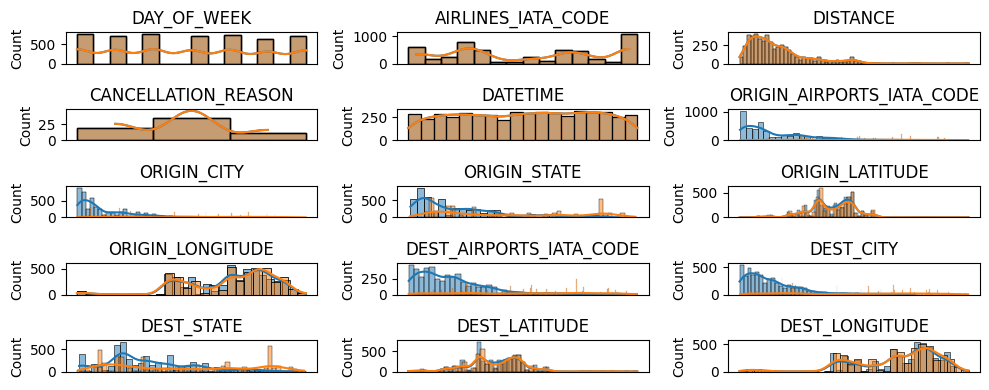

In [45]:
df_hist_compare(df_imputed_oring_knn, df, 
                label_1='imputed', label_2='original', n_rows=5)

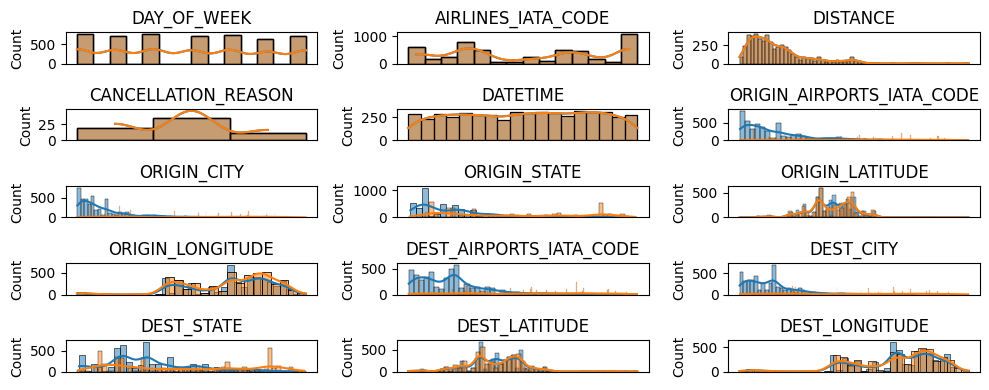

In [46]:
df_hist_compare(df_imputed_oring_iterative, df, 
                label_1='imputed', label_2='original', n_rows=5)

As we can see imputing category is not so simple, but we can keep numeric values from knn and add to our dataset. For categorical we can add existent category and drop the imputed one.
We can also kee imputed values if they are like the original one. We are using `Original KNN Imputed DataFrame` as a source of imputed data. 


We can also cosider the dataset of US flight a partition of global flight, then sometimes missing data are related to MNAR data type like, for example the destination or arrival in different world country.

In [47]:
# -------------------------------------------------------------------
# Build final dataset: fill only NaN from KNN-imputed dataset
# -------------------------------------------------------------------

from pandas.api.types import is_numeric_dtype

def merge_imputed_into_original(df_original: pd.DataFrame,
                                df_imputed: pd.DataFrame,
                                columns: list[str] | None = None) -> pd.DataFrame:
    """
    Copy original dataset and fill only missing values using imputed data.

    Rules:
    - numeric/float destination columns: fill NaN with imputed values
    - categorical destination columns: fill only if imputed value is in
      destination categories
    """
    df_out = df_original.copy(deep=True)
    report = []

    for col in df_out.columns:
        if col not in df_imputed.columns:
            continue
        
        curr_type = str(df_out[col].dtype.name)

        dst = df_out[col]
        src = df_imputed[col]
        mask_na = dst.isna()
        mask_nul = dst.isnull()


        # numeric destination: allow numeric fill only
        if curr_type in ['int64', 'float64']:
            valid_mask = (mask_na & src.notna()) | (mask_nul & src.notnull())
            if valid_mask.any():
                df_out.loc[valid_mask, col] = src.loc[valid_mask]

        # categorical destination: fill only with allowed categories
        elif curr_type == 'category':
            allowed = set(dst.cat.categories.tolist())
            src_cast = src.astype("category").cat.set_categories(allowed)
            valid_mask = mask_na & src_cast.isin(allowed)
            if valid_mask.any():
                df_out.loc[valid_mask, col] = src_cast.loc[valid_mask]

        # other dtypes are intentionally skipped
        else:
            continue

        report.append({
            "column": col,
            "missing_before": int(mask_na.sum()),
            "missing_after": int(df_out[col].isna().sum()),
        })

    return df_out, pd.DataFrame(report)


# source and destination according to requested workflow
df_final_imputed, df_final_fill_report = merge_imputed_into_original(
    df_original=df,
    df_imputed=df_imputed_oring_knn,
    columns=imputed_fiels,
)

print("Final dataset created: df_final_imputed")
print(f"Rows: {df_final_imputed.shape[0]} | Columns: {df_final_imputed.shape[1]}")
display(df_final_fill_report)

Final dataset created: df_final_imputed
Rows: 5000 | Columns: 16


,column,missing_before,missing_after
0,DAY_OF_WEEK,0,0
1,AIRLINES_IATA_CODE,0,0
2,DISTANCE,0,0
3,CANCELLATION_REASON,4935,4935
4,ORIGIN_AIRPORTS_IATA_CODE,468,468
5,ORIGIN_CITY,468,468
6,ORIGIN_STATE,468,468
7,ORIGIN_LATITUDE,474,0
8,ORIGIN_LONGITUDE,474,0
9,DEST_AIRPORTS_IATA_CODE,468,468


In [48]:
# -------------------------------------------------------------------
# Drop records with nulls because of MNAR, we have computed o small amount 
# of MAR (latitude and longitude) 
# -------------------------------------------------------------------

# pick the final merged dataset available in session
df_base_final = df_final_imputed.copy()
# keep CANCELLATION_REASON nullable by design
nullable_cols = {'CANCELLATION_REASON'}
not_nullable_cols = [c for c in df_base_final.columns if c not in nullable_cols]

rows_before = len(df_base_final)
df_final_clean = df_base_final.dropna(subset=not_nullable_cols).copy()
rows_after = len(df_final_clean)

print(f'Rows before: {rows_before}')
print(f'Rows after:  {rows_after}')
print(f'Dropped:     {rows_before - rows_after}')



Rows before: 5000
Rows after:  4532
Dropped:     468


In [49]:
print("We comparing distributions between original and our final dataset version:")
print(compare_distributions(df, df_base_final, ))

print("We comparing distributions between original and KNN imputed data:")
print(compare_distributions(df, df_imputed_oring_knn, ))
df_final_clean.info(show_counts=True)

# Boolean DataFrame mask required by compute_statistical_tests (one column per feature)
missing_mask = df.isna()
missing_mask = missing_mask.loc[:, missing_mask.any(axis=0)]

from statlib.missig_values import compute_statistical_tests
import warnings
with warnings.catch_warnings(record=True) as w:
    warnings.simplefilter("always")
    res = compute_statistical_tests(df_numeric, missing_mask)
    for warning in w:
        continue
print(f'Hypothesis tests performed on {res.keys()}\n\n')

We comparing distributions between original and our final dataset version:


0.28538317964738363
We comparing distributions between original and KNN imputed data:
0.28538317964738363
<class 'pandas.DataFrame'>
Index: 4532 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   DAY_OF_WEEK                4532 non-null   int64         
 1   AIRLINES_IATA_CODE         4532 non-null   category      
 2   DISTANCE                   4532 non-null   int64         
 3   CANCELLATION_REASON        62 non-null     category      
 4   DATETIME                   4532 non-null   datetime64[us]
 5   ORIGIN_AIRPORTS_IATA_CODE  4532 non-null   category      
 6   ORIGIN_CITY                4532 non-null   category      
 7   ORIGIN_STATE               4532 non-null   category      
 8   ORIGIN_LATITUDE            4532 non-null   float64       
 9   ORIGIN_LONGITUDE           4532 non-null   float64       
 10  DEST_AIRPORTS_IATA_CODE    4532 non-null  

In [50]:
# 'CANCELLATION_REASON', 
# null value in this filed are permitted
# but is the ost significative colums because the total
# delay of this part is snormalizedet to the maximum value
interesting_columns = ["TOTAL_DELAY","DEST_LONGITUDE",
                       "DEST_LONGITUDE","ORIGIN_LATITUDE",
                       "ORIGIN_LONGITUDE","DISTANCE"]
res['CANCELLATION_REASON'].loc[interesting_columns]

,Missing CANCELLATION_REASON,Non-missing CANCELLATION_REASON,p-value
TOTAL_DELAY,0.0 [0.0-14.0] - 4935,1615.0 [1615.0-1615.0] - 65,NaN
DEST_LONGITUDE,-90.3 [-106.9--81.3] - 4467,-87.9 [-97.0--80.2] - 61,0.052
DEST_LONGITUDE,-90.3 [-106.9--81.3] - 4467,-87.9 [-97.0--80.2] - 61,0.052
ORIGIN_LATITUDE,37.3 [33.4-40.8] - 4464,37.6 [33.4-40.9] - 62,0.807
ORIGIN_LONGITUDE,-90.5 [-112.0--81.8] - 4464,-88.6 [-97.0--80.3] - 62,0.228
DISTANCE,651.0 [386.0-1068.0] - 4935,612.0 [337.0-867.0] - 65,0.181


# Description of this step
In this last version we have a dataset without empty value now we can go to the next step of pur analisys

# Outlier detection

Explaining basic math behind the hood.

## **METHODS:**

* Supervised
* Unsupervised methods
* Statistical methods (Parametric & Nonparametric)
* Proximity-based methods

---

**Formula (Z-score):**
$$
z = \frac{x - \mu}{\sigma}
$$

Interpretation:

* Parametric univariate method assuming normality.
* Points beyond a threshold (e.g., $\pm 3\sigma$, covering 99.7% of data) are flagged as outliers.

Example:

* Detecting extreme values in a single normally distributed feature.

Python:

```python
from scipy.stats import zscore
outliers = np.abs(zscore(df[col])) > 3
```

---

**Formula (Mahalanobis Distance / $\chi^2$):**
$$
MD^2(x) = (x - \mu)^T \Sigma^{-1} (x - \mu) \sim \chi^2(d)
$$

where:
* $d$ = number of dimensions (degrees of freedom)

Interpretation:

* Multivariate parametric extension of z-score that accounts for feature correlations.
* Outliers are points whose squared Mahalanobis distance exceeds the $\chi^2$ distribution quantile.

Example:

* Identifying multivariate anomalies in correlated, approximately Gaussian data.

Python:

```python
from sklearn.covariance import MinCovDet
from scipy.stats import chi2
robust_cov = MinCovDet().fit(X)
md2 = robust_cov.mahalanobis(X)
outliers = md2 > chi2.ppf(0.95, df=X.shape[1])
```

---

**Formula (Boxplot / IQR):**
$$
\text{Outlier if } x < Q1 - 1.5 \cdot IQR \;\text{ or }\; x > Q3 + 1.5 \cdot IQR
$$

where:
* $IQR = Q3 - Q1$

Interpretation:

* Nonparametric univariate method.
* Uses quartiles to define a robust range; points in the extreme tails are marked as outliers.

Example:

* Quick screening of skewed or heavy-tailed univariate data without distributional assumptions.

Python:

```python
Q1, Q3 = np.quantile(x, [0.25, 0.75])
IQR = Q3 - Q1
outliers = (x < Q1 - 1.5 * IQR) | (x > Q3 + 1.5 * IQR)
```

---

**Formula (Kernel Density Estimate - KDE):**
$$
f_h(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)
$$

where:
* $h$ = bandwidth, $K(\cdot)$ = kernel function (e.g., Gaussian)

Interpretation:

* Nonparametric density estimation method.
* Low-density points (typically the lowest fraction, e.g., 2%) are considered outliers.

Example:

* Detecting rare patterns or anomalies in complex, multimodal distributions.

Python:

```python
from sklearn.neighbors import KernelDensity
kde = KernelDensity(bandwidth=1.0).fit(X)
scores = kde.score_samples(X)
outliers = scores <= np.quantile(scores, 0.02)
```

---

**Formula (DBSCAN):**
$$
\text{Outlier if } |N_\epsilon(x)| < m
$$

where:
* $N_\epsilon(x)$ = neighbors within radius $\epsilon$
* $m$ = minimum points required for core status

Interpretation:

* Density-based proximity method.
* Isolates points in sparse regions (noise) as outliers (assigned label $-1$).

Example:

* Spatial anomaly detection in datasets with clearly separated dense clusters.

Python:

```python
from sklearn.cluster import DBSCAN
model = DBSCAN(eps=epsilon, min_samples=m).fit(X)
outliers = model.labels_ == -1
```

---

**Formula (Local Outlier Factor - LOF):**
$$
LOF_k(x_i) = \frac{1}{|N_k(x_i)|} \sum_{x' \in N_k(x_i)} \frac{l\rho_k(x')}{l\rho_k(x_i)}
$$

where:
* $l\rho_k$ = local reachability density
* $N_k$ = set of k-nearest neighbors

Interpretation:

* Proximity-based method comparing local density to that of neighbors.
* $LOF \approx 1$ for normal points; $LOF \gg 1$ indicates outliers. Handles varying cluster densities effectively.

Example:

* Anomaly detection in datasets with non-uniform cluster spreads and densities.

Python:

```python
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors=k, contamination=c)
outliers = lof.fit_predict(X) == -1
```



Can we have a quick look of a ouliers distrubution?
now we'll use the PCA for plotting

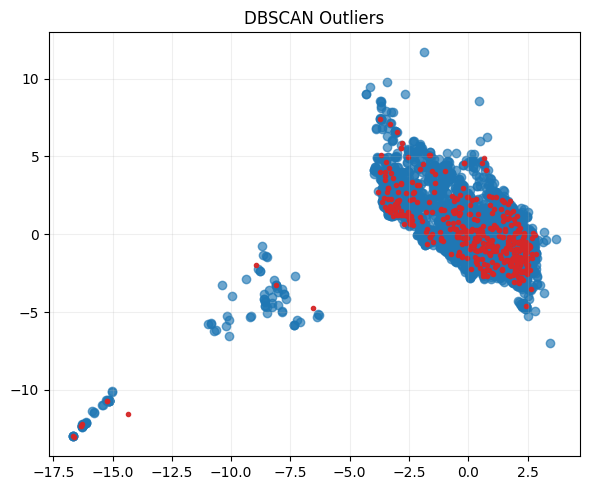

In [51]:
%reload_ext autoreload
from statlib.outliers import outliers_mask, cast_numeric_dummy_category, plot_pca_2d
# get our dataframe into numeric
df_numeric_hot, _ = cast_numeric_dummy_category(df_final_clean, category_encoding="dummy")
outlier_mask = outliers_mask(df_numeric_hot , method="dbscan",)
plot_pca_2d(df_numeric_hot, outlier_mask=outlier_mask, title="DBSCAN Outliers", seed=GLOBAL_SEED, )



In this condition we also gie a quinck look for our previous analisys of nullified values testing kde code for nullified numeric and not nullified numeric dataset

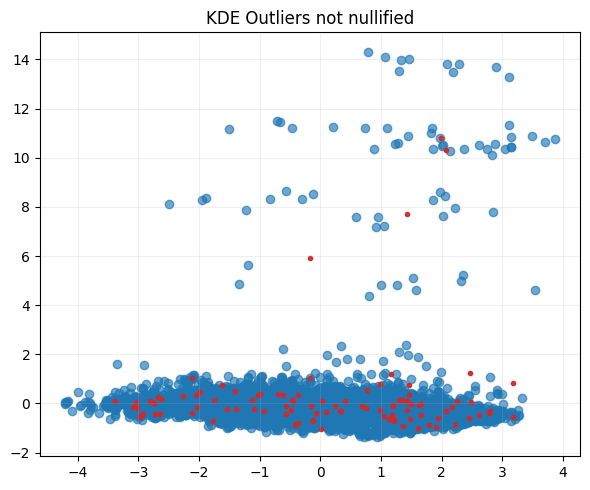

In [52]:
%reload_ext autoreload
from statlib.outliers import outliers_mask, cast_numeric_dummy_category, plot_pca_2d
# get our dataframe into numeric
df_numeric_hot, _ = cast_numeric_dummy_category(df_final_clean, category_encoding="codes")
outlier_mask = outliers_mask(df_numeric_hot , method="kde",)
plot_pca_2d(df_numeric_hot, outlier_mask=outlier_mask, title="KDE Outliers not nullified", seed=GLOBAL_SEED, )

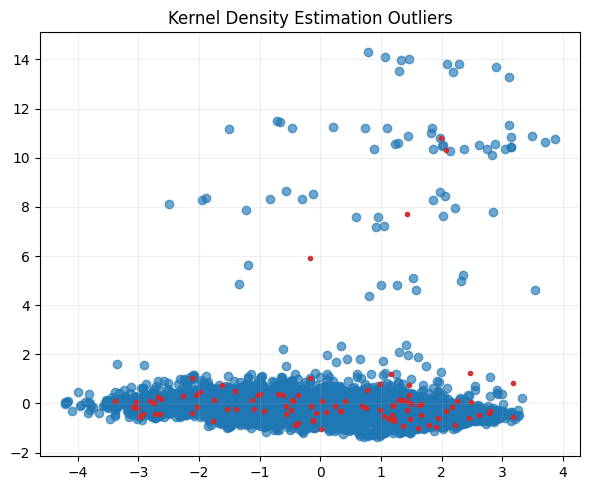

In [53]:
%reload_ext autoreload
df_numeric_hot, _ = cast_numeric_dummy_category(df_final_clean, category_encoding="codes")
outlier_mask = outliers_mask(df_numeric_hot , method="kde",)
plot_pca_2d(df_numeric_hot, outlier_mask=outlier_mask, title="Kernel Density Estimation Outliers", seed=GLOBAL_SEED, )


/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/sklearn/neighbors/_lof.py:325: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


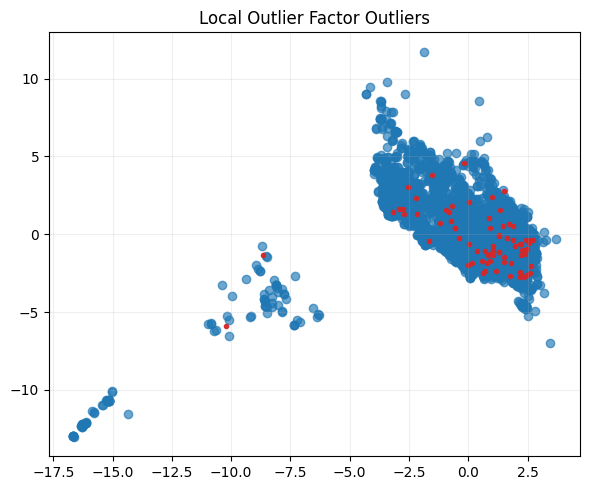

In [54]:
%reload_ext autoreload
df_numeric_hot, _ = cast_numeric_dummy_category(df_final_clean, category_encoding="dummy")
outlier_mask = outliers_mask(df_numeric_hot , method="lof", )
plot_pca_2d(df_numeric_hot, outlier_mask=outlier_mask, title="Local Outlier Factor Outliers", seed=GLOBAL_SEED, )


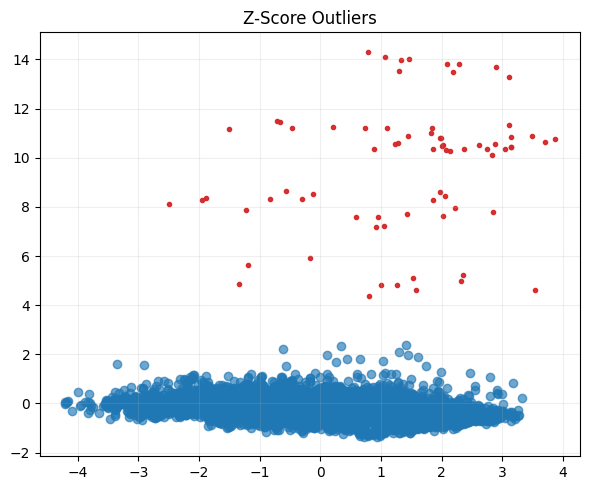

In [55]:
# how can i reload the original dataset without re-executing all the previous steps?
%reload_ext autoreload
from statlib.outliers import *
df_numeric_hot, _ = cast_numeric_dummy_category(df_final_clean, category_encoding="codes")
outlier_mask = outliers_mask(df_numeric_hot , method="zscore", value_1=7)
plot_pca_2d(df_numeric_hot, outlier_mask=outlier_mask, title="Z-Score Outliers", seed=GLOBAL_SEED, )


As we can see, we ahave 3 main cluster in this dataset, and the outlier as distributed sparsely around those clusters.

No more data deletion will be applied in this dataset, we can use this dataset for estimate the delay time

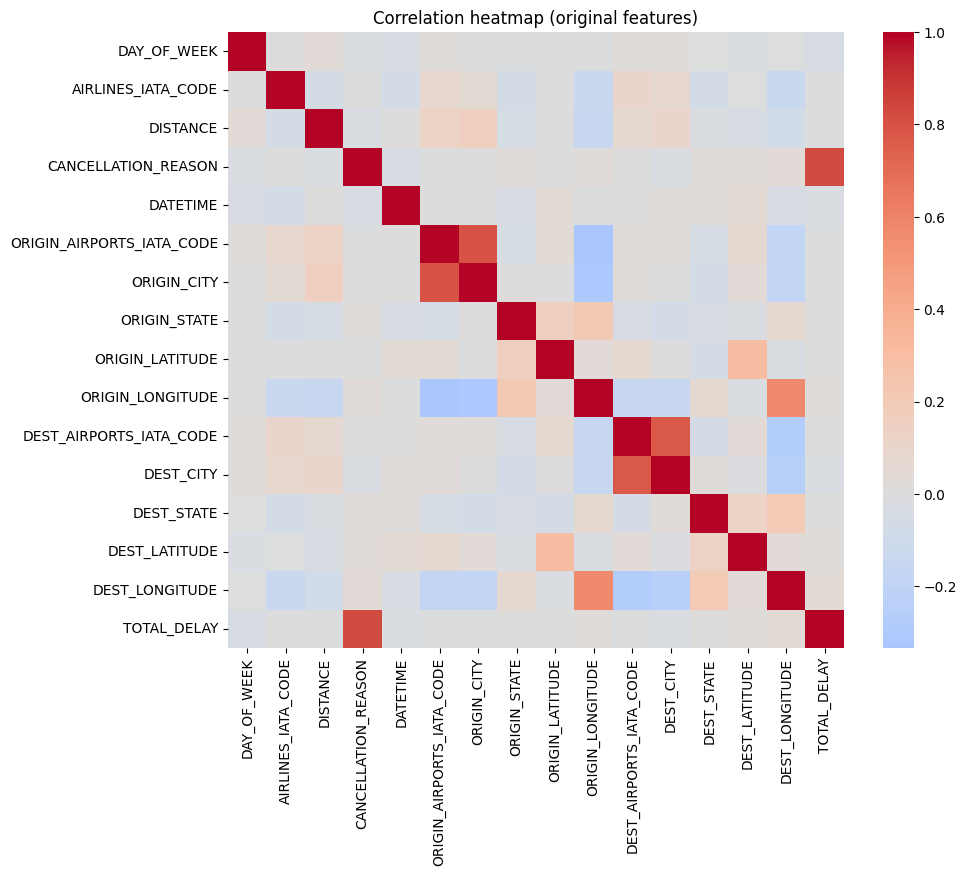

In [56]:

import seaborn as sns
# Correlation matrix
corr = df_numeric_hot.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap (original features)")
plt.show()

We have a poor correlation, so we can't have good hope to train a good model using this dataset, then we create the pipeline ad check more different analisys.


Do we need to use a all components in our linear model?
For example the codes of destination and origin city can be ignored to simplify the coun 

In [57]:
drop_columns=["DATETIME","ORIGIN_CITY","DEST_CITY", "ORIGIN_STATE","DEST_STATE",]

df_numeric_hot, _ = cast_numeric_dummy_category(df_final_clean.drop(columns=drop_columns), category_encoding="dummy")

from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Fit full PCA

pipe_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA()),
])
pipe_pca.fit(df_numeric_hot)
df_numeric_hot_scaled = pipe_pca.named_steps["scaler"].transform(df_numeric_hot)

Number of components for 90% explained variance: 420


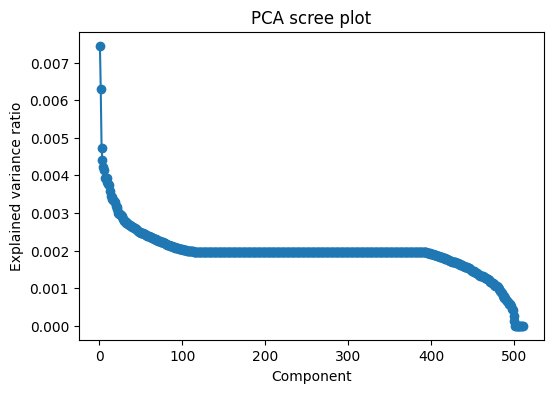

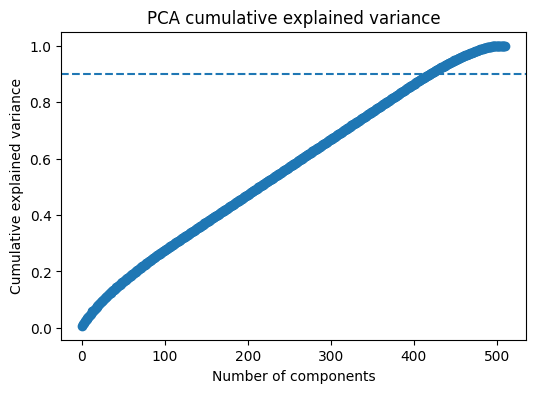

In [58]:
evr = pipe_pca.named_steps["pca"].explained_variance_ratio_
cum_evr = np.cumsum(evr)

# Smallest number of PCs explaining at least 90% variance
n_90 = np.argmax(cum_evr >= 0.90) + 1
print(f"Number of components for 90% explained variance: {n_90}")

# Scree plot
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(evr) + 1), evr, marker='o')
plt.xlabel("Component")
plt.ylabel("Explained variance ratio")
plt.title("PCA scree plot")
plt.show()

# Cumulative explained variance
plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_evr) + 1), cum_evr, marker='o')
plt.axhline(0.90, linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("PCA cumulative explained variance")
plt.show()

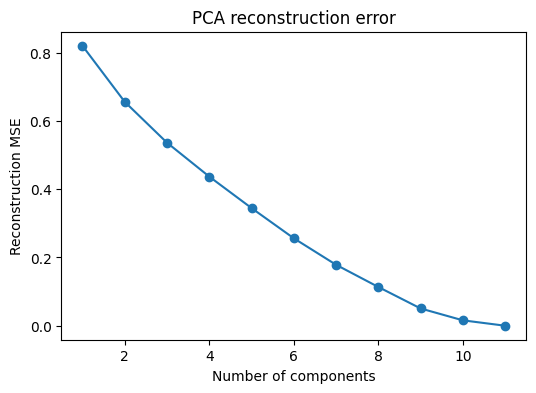

In [59]:
from sklearn.metrics import mean_squared_error
df_numeric_hot, _ = cast_numeric_dummy_category(df_final_clean.drop(columns=drop_columns), category_encoding="codes")
df_numeric_hot_scaled = StandardScaler().fit_transform(df_numeric_hot)


dims = range(1, df_numeric_hot_scaled.shape[1] + 1)
recon_errors = []

for d in dims:
    pca = PCA(n_components=d)
    X_proj = pca.fit_transform(df_numeric_hot_scaled)
    X_rec = pca.inverse_transform(X_proj)
    err = mean_squared_error(df_numeric_hot_scaled, X_rec)
    recon_errors.append(err)

plt.figure(figsize=(6, 4))
plt.plot(dims, recon_errors, marker='o')
plt.xlabel("Number of components")
plt.ylabel("Reconstruction MSE")
plt.title("PCA reconstruction error")
plt.show()

Kernel PCA components for 90% kernel variance: 2640


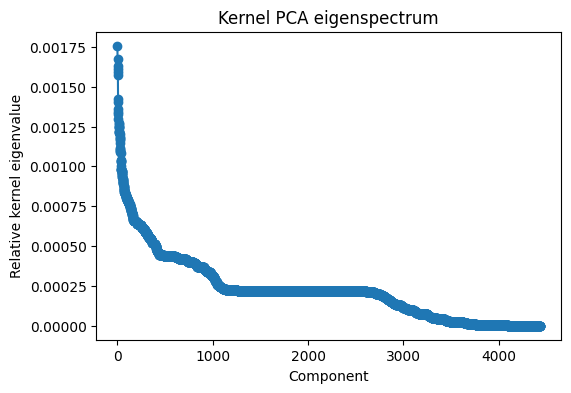

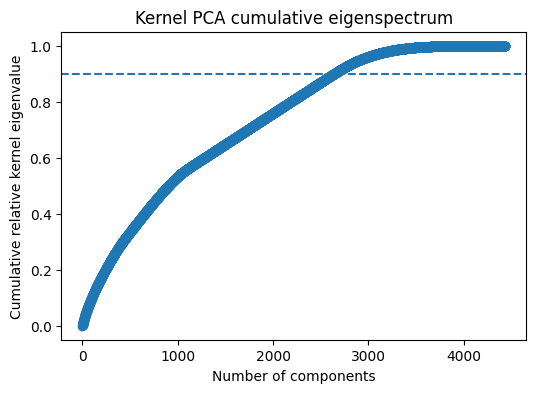

In [60]:
from sklearn.decomposition import KernelPCA

df_numeric_hot, _ = cast_numeric_dummy_category(df_final_clean.drop(columns=drop_columns), category_encoding="dummy")
df_numeric_hot_scaled = StandardScaler().fit_transform(df_numeric_hot)

# RADIAL BASIS FUNCTION, I.E. RADIAL KERNEL
kpca_full_rbf = KernelPCA(
    n_components=None,
    kernel="rbf",
    gamma=0.1,
    fit_inverse_transform=False,
    eigen_solver="auto"
)

kpca_full_rbf.fit(df_numeric_hot_scaled)

# Depending on sklearn version, this may be available as eigenvalues_ or lambdas_
eigvals = kpca_full_rbf.eigenvalues_

eigvals_ratio = eigvals / eigvals.sum()
cum_eigvals_ratio = np.cumsum(eigvals_ratio)

n_90_kpca = np.argmax(cum_eigvals_ratio >= 0.90) + 1
print(f"Kernel PCA components for 90% kernel variance: {n_90_kpca}")

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(eigvals_ratio) + 1), eigvals_ratio, marker='o')
plt.xlabel("Component")
plt.ylabel("Relative kernel eigenvalue")
plt.title("Kernel PCA eigenspectrum")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_eigvals_ratio) + 1), cum_eigvals_ratio, marker='o')
plt.axhline(0.90, linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative relative kernel eigenvalue")
plt.title("Kernel PCA cumulative eigenspectrum")
plt.show()

Kernel PCA components for 90% kernel eigenvalue mass: 283


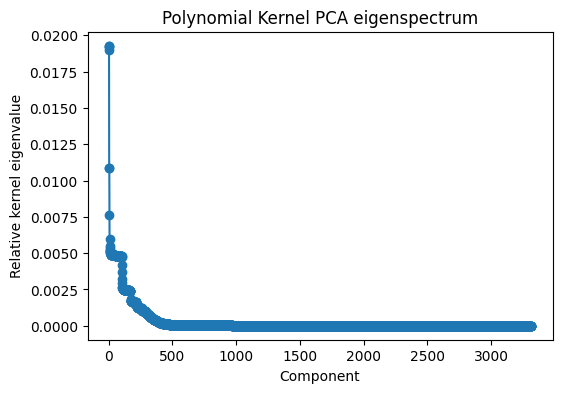

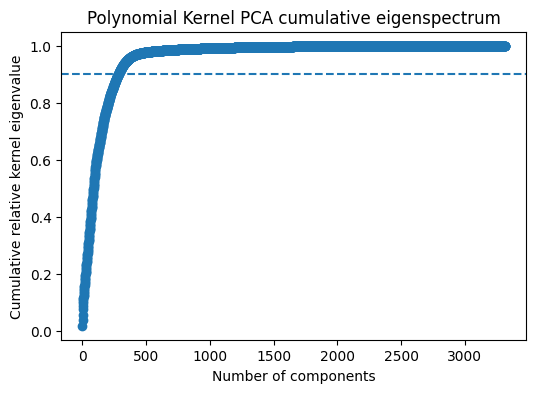

In [61]:
# POLYNOMIAL KERNEL

kpca_full_poly = KernelPCA(
    n_components=None,
    kernel="poly",
    degree=2,          # polynomial degree
    gamma=1.0,         # scaling of inner product
    coef0=1.0,         # adds lower-order terms
    fit_inverse_transform=False,
    eigen_solver="auto"
)

kpca_full_poly.fit(df_numeric_hot_scaled)

# sklearn version compatibility
eigvals = getattr(kpca_full_poly, "eigenvalues_", None)
if eigvals is None:
    eigvals = kpca_full_poly.lambdas_

eigvals_ratio = eigvals / eigvals.sum()
cum_eigvals_ratio = np.cumsum(eigvals_ratio)

n_90_kpca = np.argmax(cum_eigvals_ratio >= 0.90) + 1
print(f"Kernel PCA components for 90% kernel eigenvalue mass: {n_90_kpca}")

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(eigvals_ratio) + 1), eigvals_ratio, marker='o')
plt.xlabel("Component")
plt.ylabel("Relative kernel eigenvalue")
plt.title("Polynomial Kernel PCA eigenspectrum")
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(range(1, len(cum_eigvals_ratio) + 1), cum_eigvals_ratio, marker='o')
plt.axhline(0.90, linestyle='--')
plt.xlabel("Number of components")
plt.ylabel("Cumulative relative kernel eigenvalue")
plt.title("Polynomial Kernel PCA cumulative eigenspectrum")
plt.show()

# CHECK VISUALIZATION CAPABILITIES

Now we will plot a reduction embettid and try to find some paterns

In [62]:

df_numeric_hot, _ = cast_numeric_dummy_category(df_final_clean.drop(columns=drop_columns), category_encoding="dummy")
df_numeric_hot_scaled = StandardScaler().fit_transform(df_numeric_hot)
tmp = pd.DataFrame(df_numeric_hot_scaled , index=df_numeric_hot.index, columns=df_numeric_hot.columns)


# can we predict binning delay instead of continous time?

# -------------------------------------------------------------------
# target plots - binned for best understanding, just a quick maual binning
# -------------------------------------------------------------------

col = 'TOTAL_DELAY'
Y_target = df_final_clean[col].copy()
X_data = tmp.drop(columns=["TOTAL_DELAY"], errors="ignore")

# Bin definitions
bins = [0,4, 14, 49, 99, 199, 399, float('inf')]
labels = ['on-time','immediate','short', 'moderate', 'long', 'very_long', 'extreme']

# Add a new column grouping the delays into 
# categories based on domain knowledge 
# for certain analyses and visualizations.

Y_target['GROUPED_DELAY'] = pd.cut(Y_target, bins=bins, labels=labels, right=False)
Y_target = Y_target['GROUPED_DELAY'].astype("category").cat.codes.astype("int64")

We now use the total delay as a target, binned as we have seen initially

In [63]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import MDS, Isomap
import umap

pca_2d = PCA(n_components=2)
kpca_2d_poly = KernelPCA(
    n_components=2,
    kernel="poly",
    degree=2,
    gamma=1.0,
    coef0=1.0
)
kpca_2d_rbf = KernelPCA( n_components=2, kernel="rbf", gamma=0.1 )
mds = MDS(n_components=2, random_state=0)
iso = Isomap(n_components=2, n_neighbors=10)
umap_model = umap.UMAP(n_components=2)

# Fit and transform
#pca_2d_proj = pca_2d.fit_transform(X_data)
#kpca_poly_proj = kpca_2d_poly.fit_transform(X_data)
#kpca_rbf_proj = kpca_2d_rbf.fit_transform(X_data)
mds_proj = mds.fit_transform(X_data)
#iso_proj = iso.fit_transform(X_data) 
#umap_proj = umap_model.fit_transform(X_data)


def plot_embedding(X_embedded, title, y):
    plt.figure(figsize=(5,4))
    plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y, cmap='coolwarm', s=10)
    plt.title(title)
    plt.show()



#plot_embedding(pca_2d_proj, "PCA", Y_target.values)
#plot_embedding(kpca_poly_proj, "Kernel PCA poly", Y_target.values)
#plot_embedding(kpca_rbf_proj, "Kernel PCA rbf", Y_target.values)
#plot_embedding(mds_proj, "MDS", Y_target.values)
#plot_embedding(iso_proj, "ISOMAP", Y_target.values)
#plot_embedding(umap_proj, "UMAP", Y_target.values)

/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


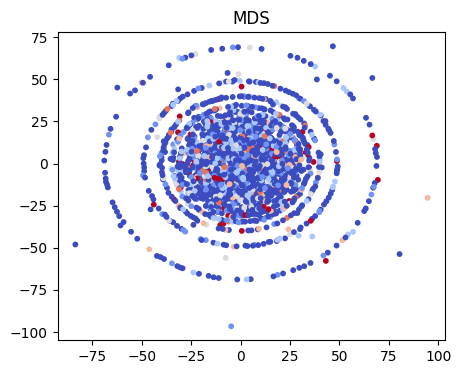

In [64]:
plot_embedding(mds_proj, "MDS", Y_target.values)

/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:744: FutureWarning: The default value of `n_init` will change from 4 to 1 in 1.9. To suppress this warning, provide some value of `n_init`.
  warnings.warn(
/media/simone/USB_projects/Usefull/ATTIVI/Esericizi/Big_data/venv/lib/python3.13/site-packages/sklearn/manifold/_mds.py:754: FutureWarning: The default value of `init` will change from 'random' to 'classical_mds' in 1.10. To suppress this warning, provide some value of `init`.
  warnings.warn(


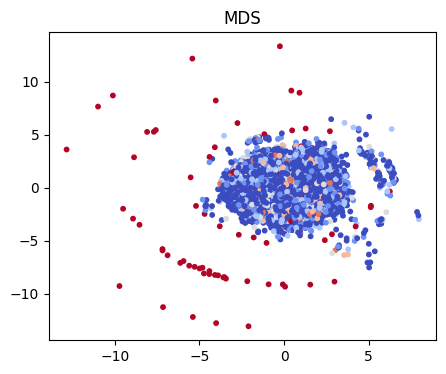

In [65]:
# using code category convertion information is plotted in a more efficient way


df_numeric_hot, _ = cast_numeric_dummy_category(df_final_clean.drop(columns=drop_columns), category_encoding="codes")
df_numeric_hot_scaled = StandardScaler().fit_transform(df_numeric_hot)
tmp = pd.DataFrame(df_numeric_hot_scaled , index=df_numeric_hot.index, columns=df_numeric_hot.columns)


# can we predict binning delay instead of continous time?

# -------------------------------------------------------------------
# target plots - binned for best understanding, just a quick maual binning
# -------------------------------------------------------------------

col = 'TOTAL_DELAY'
Y_target = df_final_clean[col].copy()
X_data = tmp.drop(columns=["TOTAL_DELAY"], errors="ignore")

# Bin definitions
bins = [0,4, 14, 49, 99, 199, 399, float('inf')]
labels = ['on-time','immediate','short', 'moderate', 'long', 'very_long', 'extreme']

# Add a new column grouping the delays into 
# categories based on domain knowledge 
# for certain analyses and visualizations.

Y_target['GROUPED_DELAY'] = pd.cut(Y_target, bins=bins, labels=labels, right=False)
Y_target = Y_target['GROUPED_DELAY'].astype("category").cat.codes.astype("int64")

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import MDS, Isomap
import umap

pca_2d = PCA(n_components=2)
kpca_2d_poly = KernelPCA(
    n_components=2,
    kernel="poly",
    degree=2,
    gamma=1.0,
    coef0=1.0
)
kpca_2d_rbf = KernelPCA( n_components=2, kernel="rbf", gamma=0.1 )
mds = MDS(n_components=2, random_state=0)
iso = Isomap(n_components=2, n_neighbors=10)
umap_model = umap.UMAP(n_components=2)

# Fit and transform
#pca_2d_proj = pca_2d.fit_transform(X_data)
#kpca_poly_proj = kpca_2d_poly.fit_transform(X_data)
#kpca_rbf_proj = kpca_2d_rbf.fit_transform(X_data)
mds_proj = mds.fit_transform(X_data)
#iso_proj = iso.fit_transform(X_data) 
#umap_proj = umap_model.fit_transform(X_data)


def plot_embedding(X_embedded, title, y):
    plt.figure(figsize=(5,4))
    plt.scatter(X_embedded[:,0], X_embedded[:,1], c=y, cmap='coolwarm', s=10)
    plt.title(title)
    plt.show()



#plot_embedding(pca_2d_proj, "PCA", Y_target.values)
#plot_embedding(kpca_poly_proj, "Kernel PCA poly", Y_target.values)
#plot_embedding(kpca_rbf_proj, "Kernel PCA rbf", Y_target.values)
plot_embedding(mds_proj, "MDS", Y_target.values)
#plot_embedding(iso_proj, "ISOMAP", Y_target.values)
#plot_embedding(umap_proj, "UMAP", Y_target.values)

Behind the scenes, we have performed a comprehensive EDA and data preprocessing workflow on the flight dataset. 
We started by visualizing the distributions of numeric and categorical features, identifying missing values, 
and understanding their patterns. 
We then applied imputation techniques (KNN and Iterative Imputer) to fill in missing values, followed by a 
careful merging process to create a final cleaned dataset.
Finally, we explored dimensionality reduction techniques (PCA, Kernel PCA, MDS) to visualize the data in 2D space,
colored by a binned version of the target variable (TOTAL_DELAY).
As a result, we have a cleaned and imputed dataset ready for further analysis or modeling, along with insights 
into the data structure and relationships.

The last plot shows the MDS projection of the data colored by the binned delay categories, 
which can help us visually assess how well the different delay groups are separated in the feature space.

The red values in the plot represent the "extreme" delay category, 
while the blue values represent the "on-time" category.

The last plot give us a little hope that we can prepare a working model
for predicting extreme values of delay, which is the most interesting part of 
the problem for user experience.

# Evalueting model

### Quality of the Linear Regression Analysis

The coefficient of determination (R-squared) measures the proportion of the variance in the dependent variable that is predictable from the independent variable(s). It provides a measure of how well the regression model fits the observed data points.

1. **Coefficient of Determination (R-squared):**
   $$ R^2 = 1 - \frac{SS_{\text{res}}}{SS_{\text{tot}}}$$

   Where:
   - $SS_{\text{res}}$ is the sum of squares of residuals
   - $ SS_{\text{tot}}$ is the total sum of squares

2. **Sum of Squares of Residuals (\(SS_{\text{res}}\)):**
   $$SS_{\text{res}} = \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

   Where:
   - $n$ is the number of observations
   - $y_i$ is the observed value of the dependent variable
   - $\hat{y}_i$ is the predicted value of the dependent variable

3. **Total Sum of Squares $SS_{\text{tot}}$:**
   $$ SS_{\text{tot}} = \sum_{i=1}^{n} (y_i - \bar{y})^2 $$

   Where:
   - $n$ is the number of observations
   - $y_i$ is the observed value of the dependent variable
   - $\bar{y}$ is the mean of the observed values of the dependent variable

In [66]:
# split the prescaled dataset but not the target into train and test sets for future modeling
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

X_train, X_test, y_train, y_test = train_test_split(
    X_data, Y_target, test_size=0.2, random_state=GLOBAL_SEED, stratify=Y_target
)

In [67]:
# show if we have a linear relationship between features and target
lr.fit(X_train,y_train)

y_pred = lr.predict(X_test)

In [73]:

MAE=mean_absolute_error(y_test,y_pred)
print(f'The Mean Absolute Error of the regression is {MAE}.')
print(f'The R2 coefficient of the regression is {r2_score(y_test,y_pred)}.')

The Mean Absolute Error of the regression is 1.0784996350825562.
The R2 coefficient of the regression is 0.16550504394200638.


As we have predict, the linear model is not so good

Can we use other model like logistic regressor just to have a simple comparison?

              precision    recall  f1-score   support

     on-time       0.60      0.19      0.29       544
   immediate       0.12      0.14      0.13       116
       short       0.10      0.05      0.07       118
    moderate       0.04      0.08      0.05        53
        long       0.04      0.19      0.07        36
   very_long       0.03      0.40      0.06        20
     extreme       0.56      0.75      0.64        20

    accuracy                           0.18       907
   macro avg       0.21      0.26      0.19       907
weighted avg       0.41      0.18      0.22       907

Balanced accuracy: 0.2571
The Mean Absolute Error of the regression is 2.374862183020948.
The R2 coefficient of the regression is -2.9476991770631646.


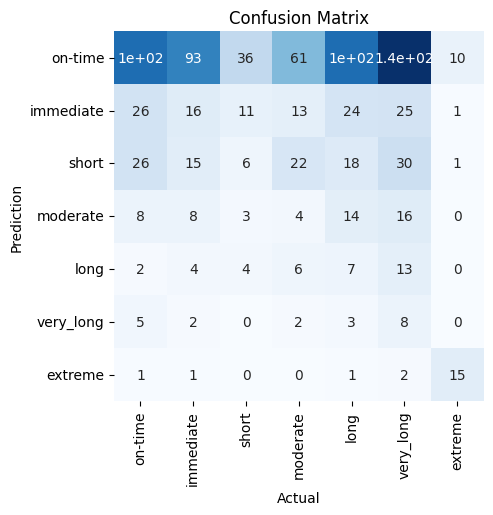

In [71]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import balanced_accuracy_score, classification_report, confusion_matrix

labels = ["on-time", "immediate", "short", "moderate", "long", "very_long", "extreme"]

# Balance classes to reduce collapse on rare delay bins.
logreg = LogisticRegression(
    max_iter=2000,
    random_state=GLOBAL_SEED,
    class_weight="balanced",
)

logreg.fit(X_train, y_train)
y_pred_class = logreg.predict(X_test)

cm = confusion_matrix(y_test, y_pred_class)  # y_true vs y_pred
sns.heatmap(
    cm,
    square=True,
    annot=True,
    cbar=False,
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
)
plt.title("Confusion Matrix")
plt.xlabel("Actual")
plt.ylabel("Prediction")

print(classification_report(y_test, y_pred_class, target_names=labels, zero_division=0))
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, y_pred_class):.4f}")


MAE=mean_absolute_error(y_test,y_pred_class)
print(f'The Mean Absolute Error of the regression is {MAE}.')
print(f'The R2 coefficient of the regression is {r2_score(y_test,y_pred_class)}.')

the result of predictable extreme value can be a bias because of
the cancelled reason filed (if we have a cenelled flight
the delay is set to the maximum value, but this is a domain bias)

# Conclusions

The model shows some ability to predict the delay categories, especially for the more common classes. 
However, performance is limited, first Linear model perfomr better than Classification model. This should be
influenced by the size of ingested data.
We have a big dataset the for having an improvement in performance, we should increase 
the representativeness of the sample by increasing the number of records ingested, 
maybe in a more balanced way than the actual that has a distribution similar to our random input dataset.